# Rosas2020CausalBlankets

In [12]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import matplotlib.pyplot as plt
import os, sys
from tqdm import tqdm
import pandas as pd
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from causal_blankets import *

In [14]:
%store -r all_partition_timeseries superagent_sizes

## Compute causal blankets

In [23]:
all_S_cs = []
all_A_cs = []
all_X_sub_flat_decimal = []
all_Y_sub_flat_decimal = []
N = len(all_partition_timeseries)
all_Exi = np.empty(N)
all_TE_A_Y = np.empty(N)
all_TE_S_X = np.empty(N)
for i in tqdm(range(len(all_partition_timeseries))):
    superagent_idx = i
    data = all_partition_timeseries[superagent_idx]

    X = data[0]
    Y = data[1]
    if Y.shape[1] == 0:
        all_TE_S_X[i] = np.nan
        all_TE_A_Y[i] = np.nan
        all_Exi[i] = np.nan
        all_A_cs.append(np.nan)
        all_S_cs.append(np.nan)
        all_X_sub_flat_decimal.append([])
        all_Y_sub_flat_decimal.append([])
        print(f"Skipping superagent {superagent_idx} because Y is empty")
        continue

    # Compute the Causal Blanket states ----------------------------------------
    # From Rosas2020CausalBlankets, Proposition 1
    A_causal_states, X_sub_flat = get_minimal_DBaSS(X, Y)  # A is a minimal D-BaSS of X w.r.t. Y
    S_causal_states, Y_sub_flat = get_minimal_DBaSS(Y, X)  # S is a minimal D-BaSS of Y w.r.t. X

    # Convert to decimal representation ------------------------------------
    Y_sub_flat_decimal = bin2dec(Y_sub_flat)
    X_sub_flat_decimal = bin2dec(X_sub_flat)
    all_X_sub_flat_decimal.append(X_sub_flat_decimal)
    all_Y_sub_flat_decimal.append(Y_sub_flat_decimal)

    # Estimate the mutual information ------------------------------------
    # E[xi] = I( X_t+1 ; Y_t+1 | X_t , Y_t)
    alphabet_sizes = {
        'alph1': 2**X_sub_flat.shape[1],
        'alph2': 2**Y_sub_flat.shape[1],
        'alphc': 2**X_sub_flat.shape[1] * 2**Y_sub_flat.shape[1],
    }
    mi_estimator = JidtDiscreteCMI(settings=alphabet_sizes)
    mi_value = mi_estimator.estimate(
        X_sub_flat_decimal[1:], 
        Y_sub_flat_decimal[1:], 
        np.hstack((X_sub_flat_decimal[:-1], Y_sub_flat_decimal[:-1]))
    )
    all_Exi[i] = mi_value

    # Get timeseries of causal state labels ------------------------------------
    A_cs = get_causal_state_timeseries(A_causal_states, X_sub_flat)
    all_A_cs.append(A_cs)

    # TE(A -> Y) = I(A_t ; Y_t+1 | Y_t)
    alphabet_sizes = {
        'alph1': 2**X_sub_flat.shape[1],
        'alph2': 2**Y_sub_flat.shape[1],
        'alphc': 2**Y_sub_flat.shape[1],
    }
    mi_estimator = JidtDiscreteCMI(settings=alphabet_sizes)
    te_value = mi_estimator.estimate(
        A_cs[:-1], 
        Y_sub_flat_decimal[1:], 
        Y_sub_flat_decimal[:-1]
    )
    all_TE_A_Y[i] = te_value
    
    S_cs = get_causal_state_timeseries(S_causal_states, Y_sub_flat)
    all_S_cs.append(S_cs)

    # TE(S -> X) = I(S_t ; X_t+1 | X_t)
    alphabet_sizes = {
        'alph1': 2**Y_sub_flat.shape[1],
        'alph2': 2**X_sub_flat.shape[1],
        'alphc': 2**X_sub_flat.shape[1],
    }
    mi_estimator = JidtDiscreteCMI(settings=alphabet_sizes)
    te_value = mi_estimator.estimate(
        S_cs[:-1], 
        X_sub_flat_decimal[1:], 
        X_sub_flat_decimal[:-1]
    )
    all_TE_S_X[i] = te_value

100%|██████████| 19/19 [00:01<00:00, 14.25it/s]

Skipping superagent 18 because Y is empty


“the “sensory” (S) and “active” (A) variables of CBs correspond (due to Definition 2) to minimal sufficient statistics that mediate the interdependencies between the past and future of X and Y .” ([Rosas et al., 2020, p. 6](zotero://select/library/items/J8Y3T5TI)) ([pdf](zotero://open-pdf/library/items/DAMDSV7G?page=6&annotation=YJJP9FPY))

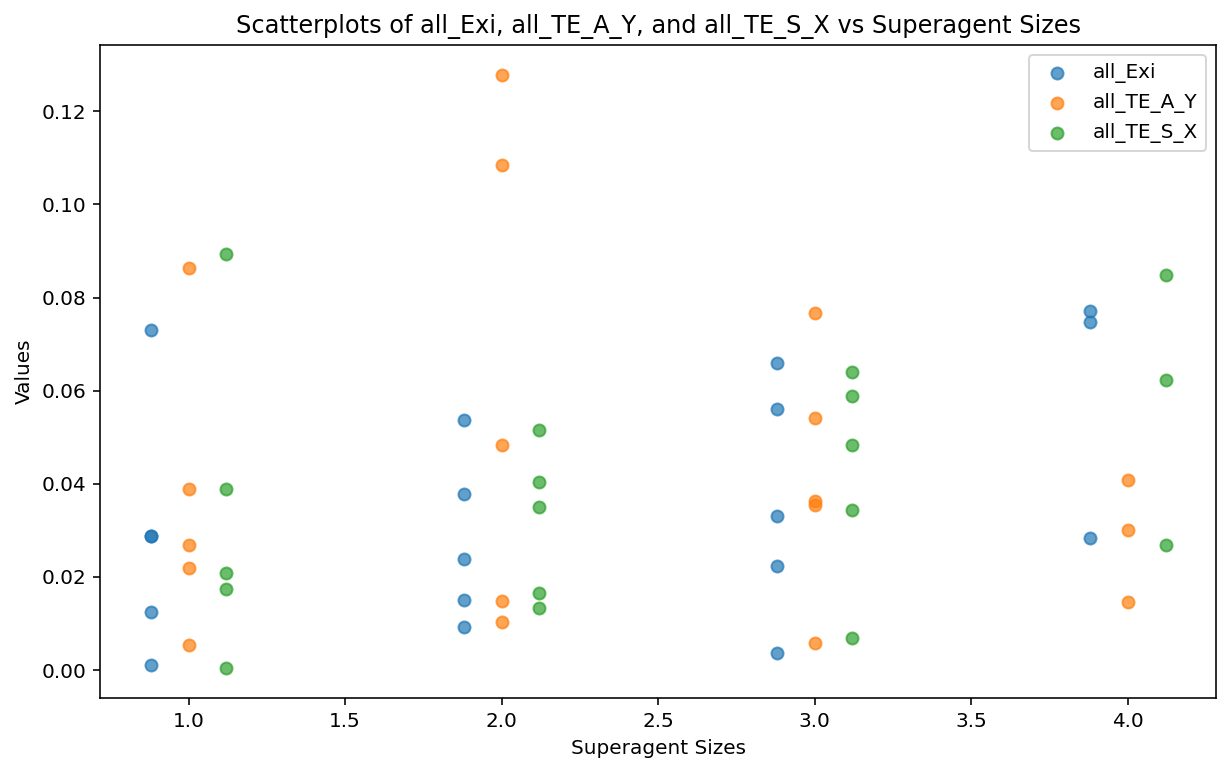

In [24]:
# Plot the scatterplots
plt.figure(figsize=(10, 6))
plt.scatter(np.array(superagent_sizes)-0.12, all_Exi, label='all_Exi', alpha=0.7)
plt.scatter(np.array(superagent_sizes), all_TE_A_Y, label='all_TE_A_Y', alpha=0.7)
plt.scatter(np.array(superagent_sizes)+0.12, all_TE_S_X, label='all_TE_S_X', alpha=0.7)

# Add labels, legend, and grid
plt.xlabel('Superagent Sizes')
plt.ylabel('Values')
plt.title('Scatterplots of all_Exi, all_TE_A_Y, and all_TE_S_X vs Superagent Sizes')
plt.legend()
# plt.grid(True)
plt.show()

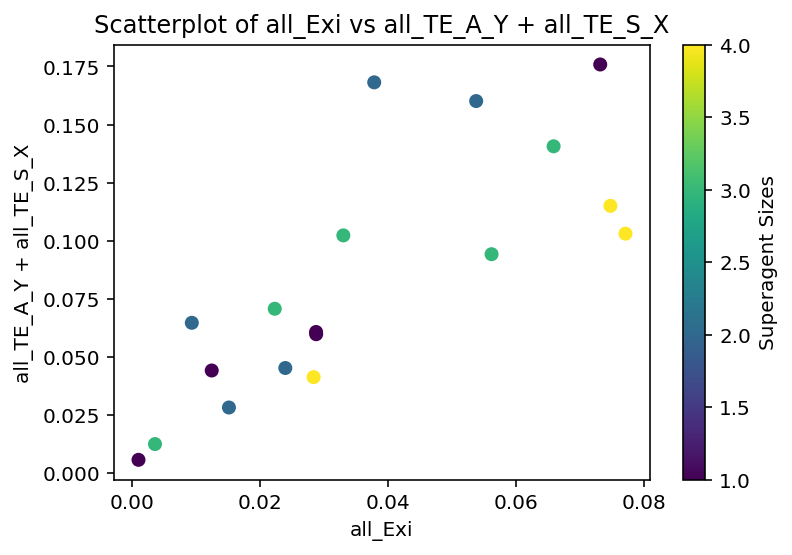

In [18]:
plt.scatter(
    all_Exi,
    all_TE_A_Y + all_TE_S_X,
    c=superagent_sizes,
)
plt.colorbar(label='Superagent Sizes')
plt.xlabel('all_Exi')
plt.ylabel('all_TE_A_Y + all_TE_S_X')
plt.title('Scatterplot of all_Exi vs all_TE_A_Y + all_TE_S_X')
plt.show()

In [8]:
# Create a pandas DataFrame
df_results = pd.DataFrame({
    'size': superagent_sizes,
    'Exi': all_Exi,
    'TE_A_Y': all_TE_A_Y,
    'TE_S_X': all_TE_S_X
})

# Display the DataFrame
print(df_results)

df_results[(df_results['size'] == 2) & ((df_results['TE_A_Y'] + df_results['TE_S_X']) > 0.15)].index
# print(filtered_results)

    size       Exi    TE_A_Y    TE_S_X
0      1  0.000971  0.005358  0.000419
1      1  0.012416  0.026769  0.017439
2      1  0.028725  0.021844  0.038935
3      2  0.009303  0.048265  0.016459
4      2  0.015107  0.014899  0.013389
5      2  0.037812  0.127837  0.040332
6      3  0.032987  0.054024  0.048304
7      1  0.028739  0.038952  0.020873
8      1  0.073134  0.086423  0.089433
9      2  0.023919  0.010384  0.034900
10     2  0.053745  0.108551  0.051574
11     3  0.056153  0.035426  0.058812
12     3  0.003551  0.005794  0.006768
13     3  0.022265  0.036345  0.034422
14     3  0.065849  0.076580  0.064083
15     4  0.028341  0.014606  0.026747
16     4  0.077082  0.040780  0.062298
17     4  0.074728  0.030122  0.084927
18     5       NaN       NaN       NaN


Int64Index([5, 10], dtype='int64')

## Bonus

In [41]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_state_machine(node_label_timeseries, edge_label_timeseries, title="State Machine"):

    # Create a directed graph
    state_machine = nx.DiGraph()

    # Add states and transitions
    for t in range(len(node_label_timeseries) - 1):
        current_state = node_label_timeseries[t]
        next_state = node_label_timeseries[t + 1]
        symbol = edge_label_timeseries[t]

        # Add the edge with the symbol as the label
        if state_machine.has_edge(current_state, next_state):
            state_machine[current_state][next_state]['label'].add(symbol)
        else:
            state_machine.add_edge(current_state, next_state, label={symbol})

    # Convert edge labels to a readable format
    edge_labels = {
        (u, v): ', '.join(map(str, sorted(data['label'])))
        for u, v, data in state_machine.edges(data=True)
    }

    # Draw the state machine
    pos = nx.spring_layout(state_machine)  # Layout for visualization
    plt.figure(figsize=(12, 8))
    nx.draw(state_machine, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=10, font_weight='bold')
    nx.draw_networkx_edge_labels(state_machine, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5)
    plt.title(title)
    plt.show()

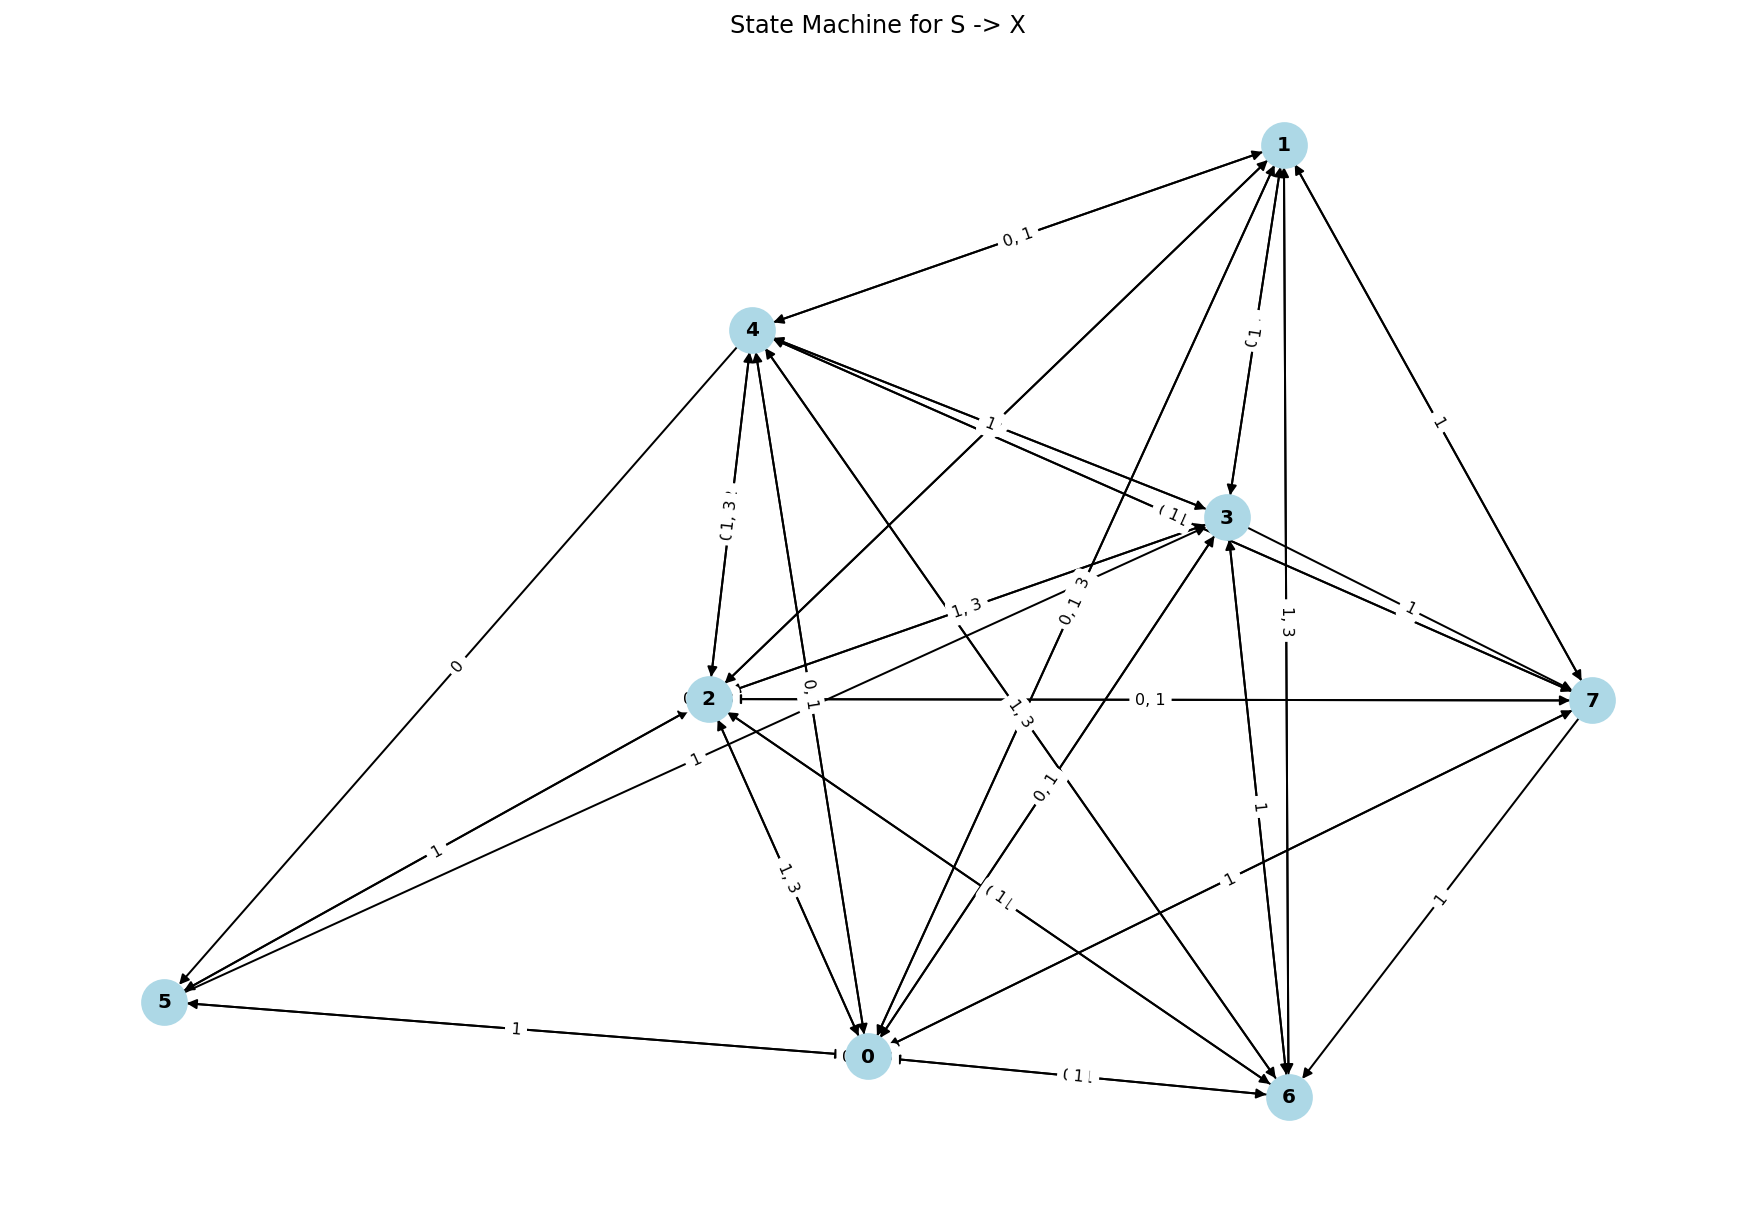

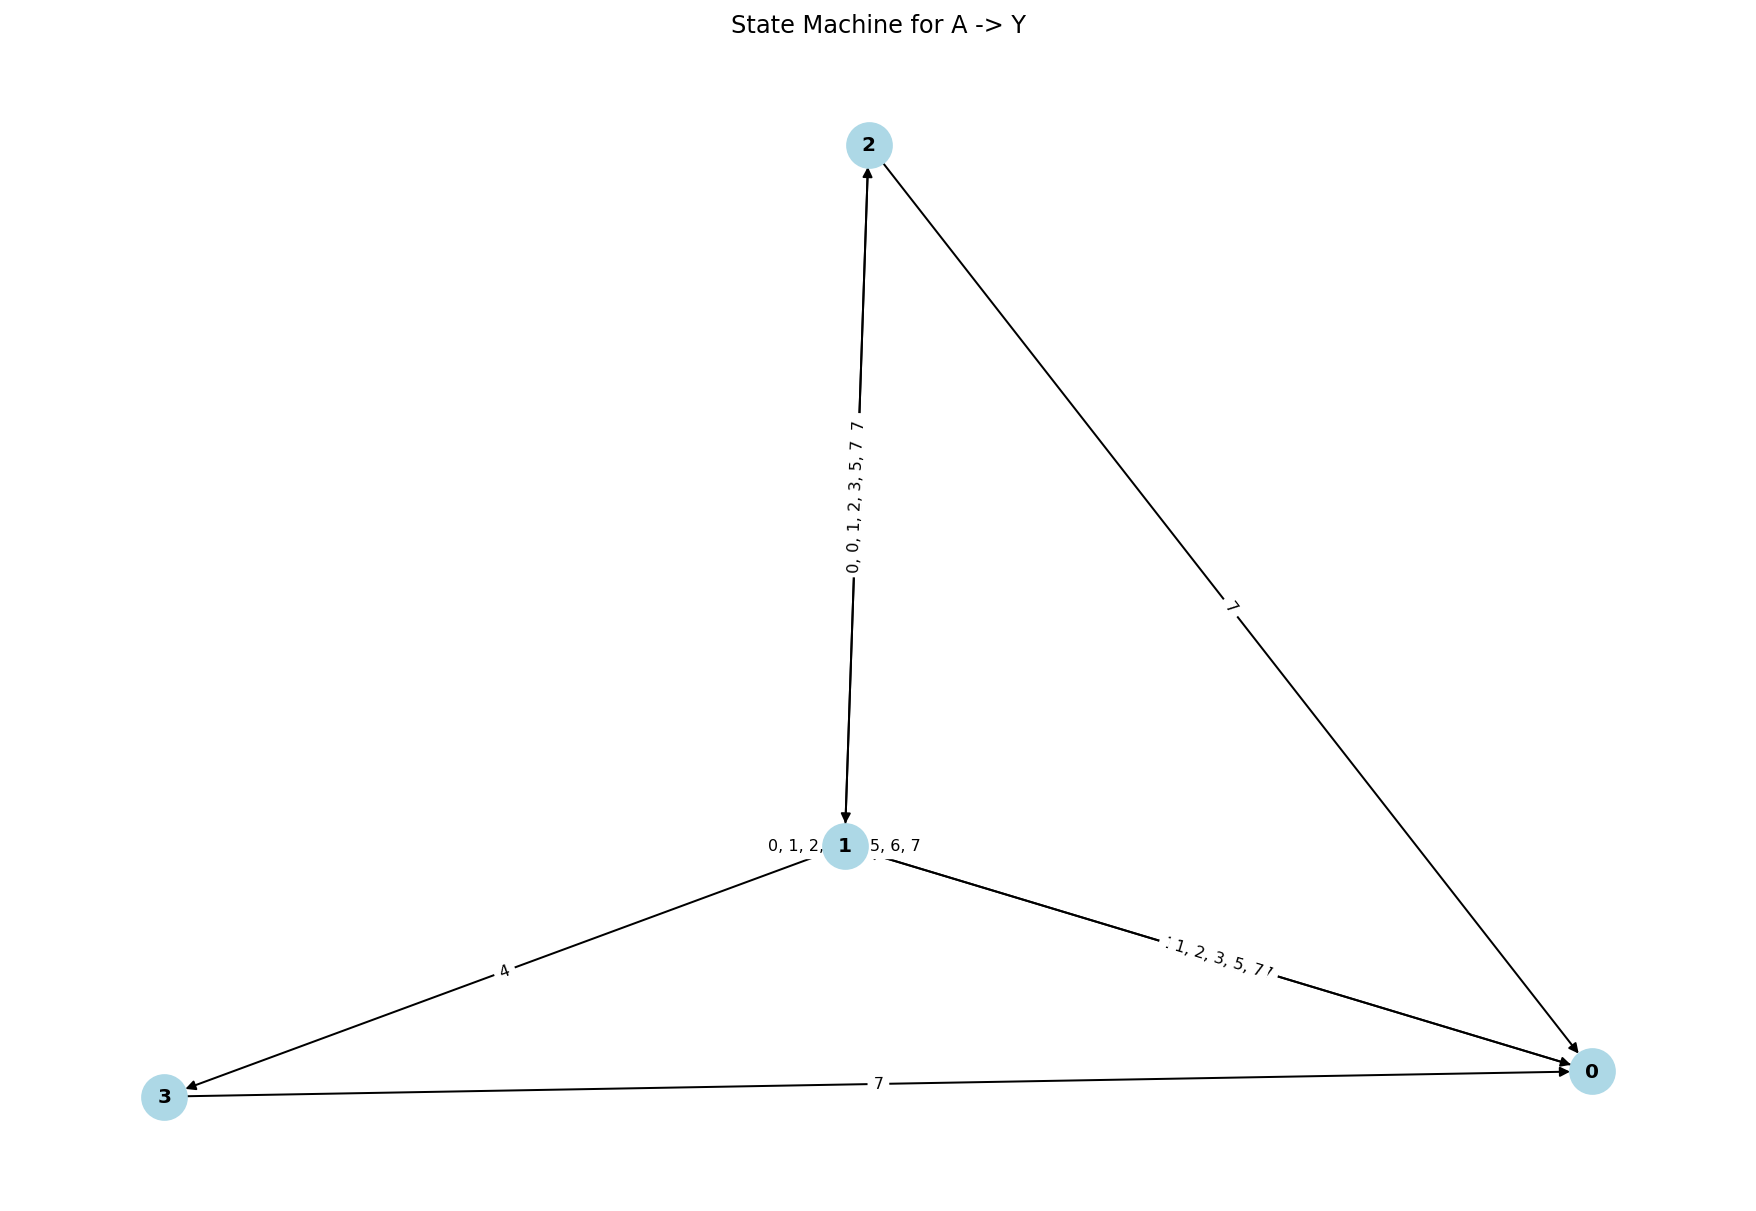

In [43]:
superagent_idx = 5
plot_state_machine(
    all_S_cs[superagent_idx],
    all_X_sub_flat_decimal[superagent_idx], 
    title="State Machine for S -> X"
)
plot_state_machine(
    all_A_cs[superagent_idx],
    all_Y_sub_flat_decimal[superagent_idx], 
    title="State Machine for A -> Y"
)

In [71]:
def build_joint_state_machine(X_sub_flat_decimal, Y_sub_flat_decimal, S_cs, A_cs):
    """
    Plots a state machine where nodes are joint (X, Y) states and edges are joint (S, A) states.

    Parameters:
    - X_sub_flat_decimal: 1D array of decimal representations of X states
    - Y_sub_flat_decimal: 1D array of decimal representations of Y states
    - S_cs: 1D array of causal states for S
    - A_cs: 1D array of causal states for A
    """
    joint_node_timeseries = np.array([
        (
            X_sub_flat_decimal[t], 
            Y_sub_flat_decimal[t]
        ) for t in range(len(X_sub_flat_decimal))
    ])

    joint_edge_timeseries = np.array([
        (
            S_cs[t], 
            A_cs[t]
        ) for t in range(len(X_sub_flat_decimal))
    ])

    # Create a directed graph
    joint_state_machine = nx.DiGraph()

    # Add states and transitions
    for t in range(len(joint_node_timeseries) - 1):
        current_state = tuple(joint_node_timeseries[t])
        next_state = tuple(joint_node_timeseries[t + 1])
        symbol = tuple(joint_edge_timeseries[t])

        # Add the edge with the symbol as the label
        if joint_state_machine.has_edge(current_state, next_state):
            joint_state_machine[current_state][next_state]['label'].add(symbol)
        else:
            joint_state_machine.add_edge(current_state, next_state, label={symbol})


    return joint_state_machine

def plot_joint_state_machine(joint_state_machine, title="Joint State Machine"):
    # Convert edge labels to a readable format
    edge_labels = {
        (u, v): ', '.join(map(str, sorted(data['label'])))
        for u, v, data in joint_state_machine.edges(data=True)
    }

    # Place nodes on a lattice based on the rank of their labels
    x_ranks = {value: rank for rank, value in enumerate(sorted(set(node[0] for node in joint_state_machine.nodes())))}
    y_ranks = {value: rank for rank, value in enumerate(sorted(set(node[1] for node in joint_state_machine.nodes())))}

    pos = {
        node: (x_ranks[node[0]], y_ranks[node[1]])
        for node in joint_state_machine.nodes()
    }

    # Draw the state machine
    plt.figure(figsize=(12, 8))
    nx.draw(joint_state_machine, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=10, font_weight='bold')
    nx.draw_networkx_edge_labels(joint_state_machine, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5)
    plt.title(title)
    plt.show()

Superagent 0 (1 agents). Causal State Machine has 4 nodes and 13 edges


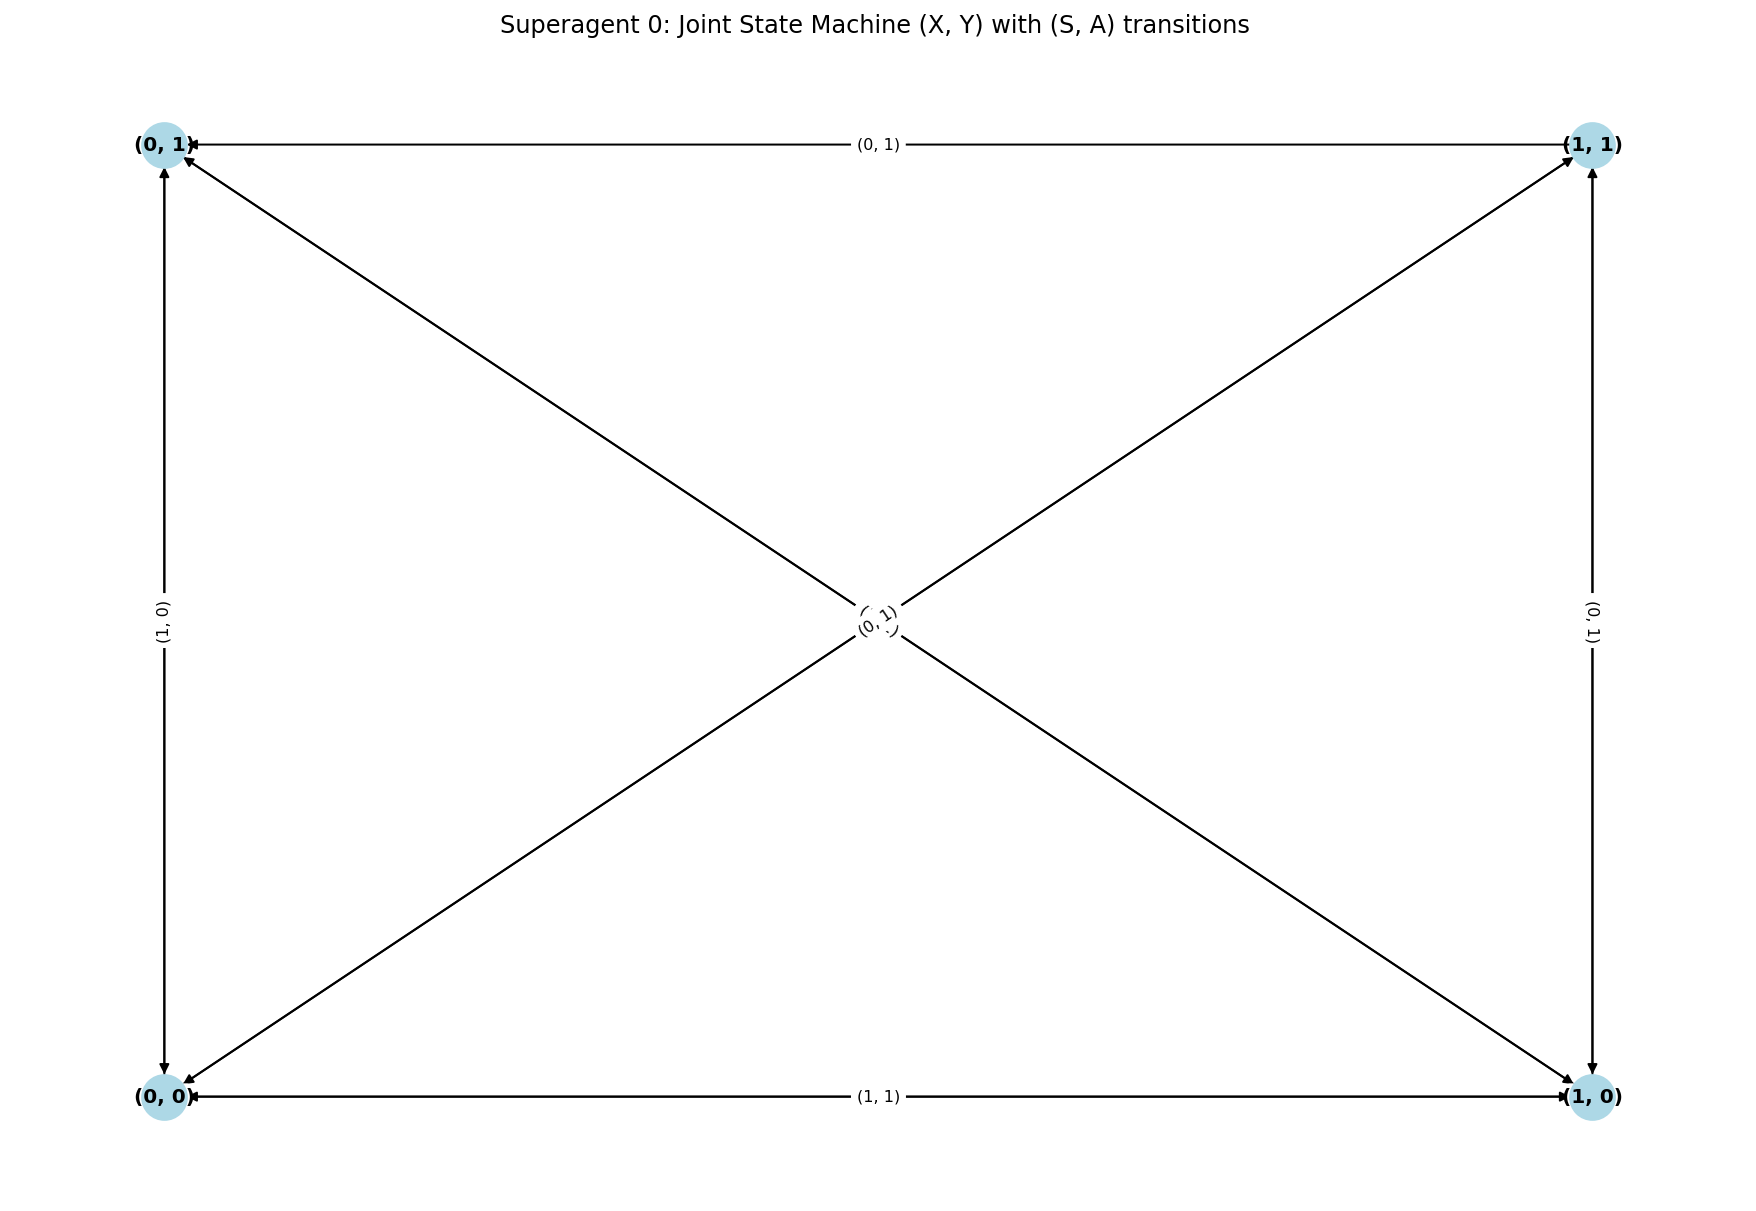

Superagent 1 (1 agents). Causal State Machine has 12 nodes and 50 edges


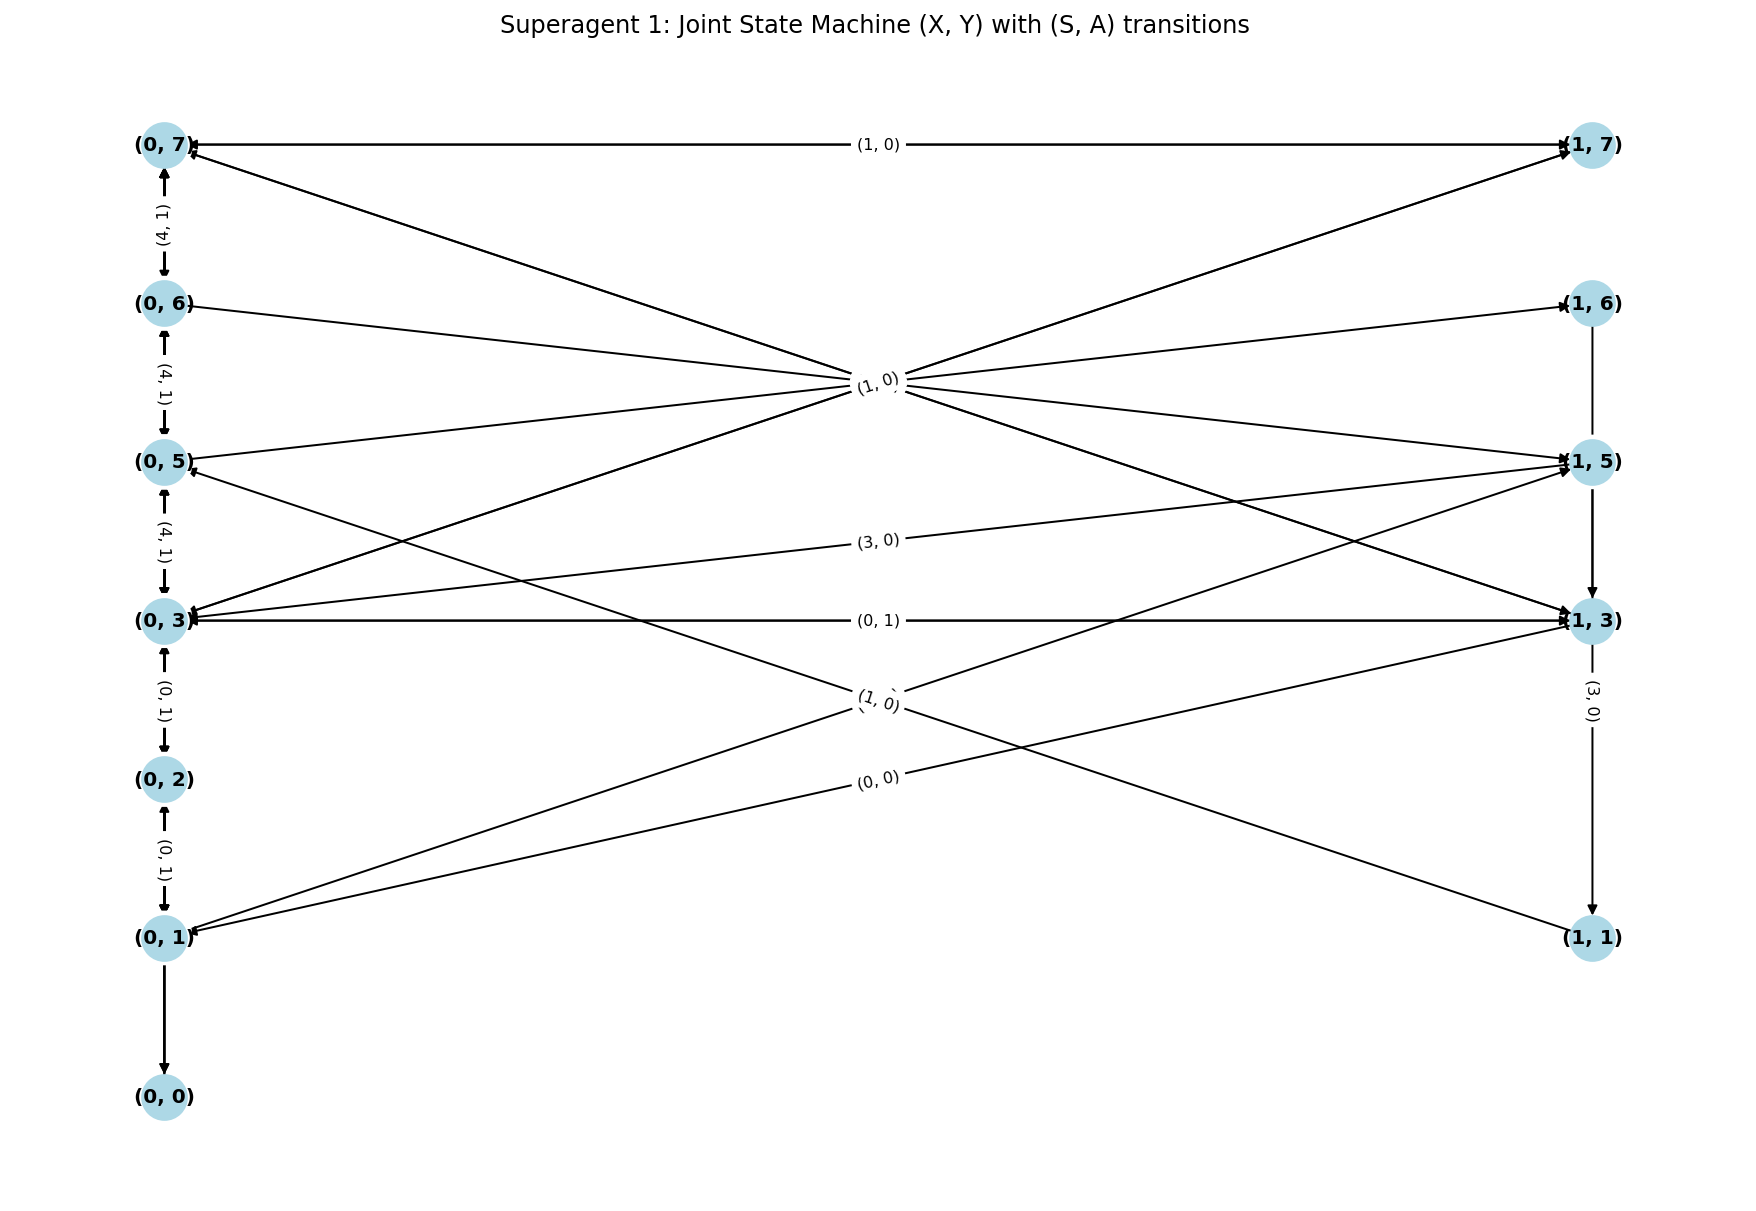

Superagent 2 (1 agents). Causal State Machine has 12 nodes and 50 edges


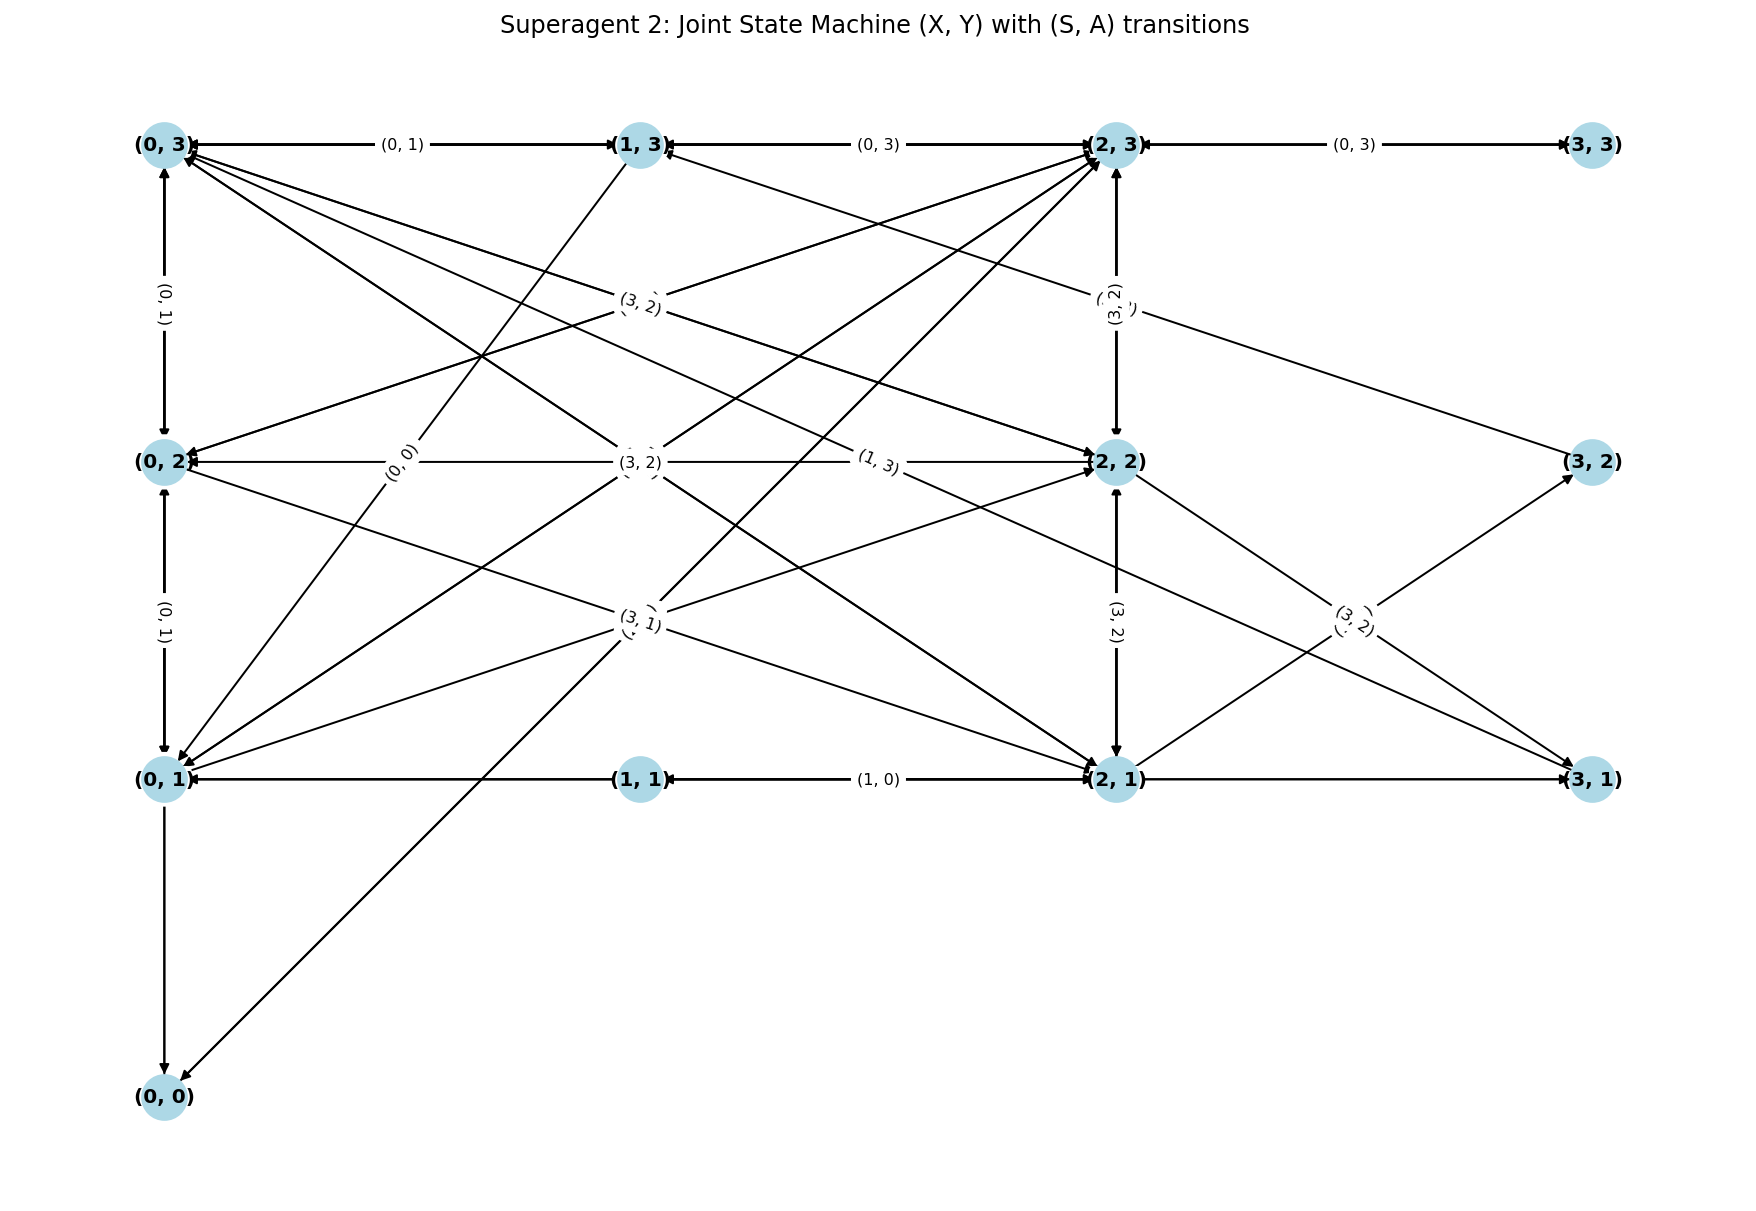

Superagent 3 (2 agents). Causal State Machine has 12 nodes and 49 edges


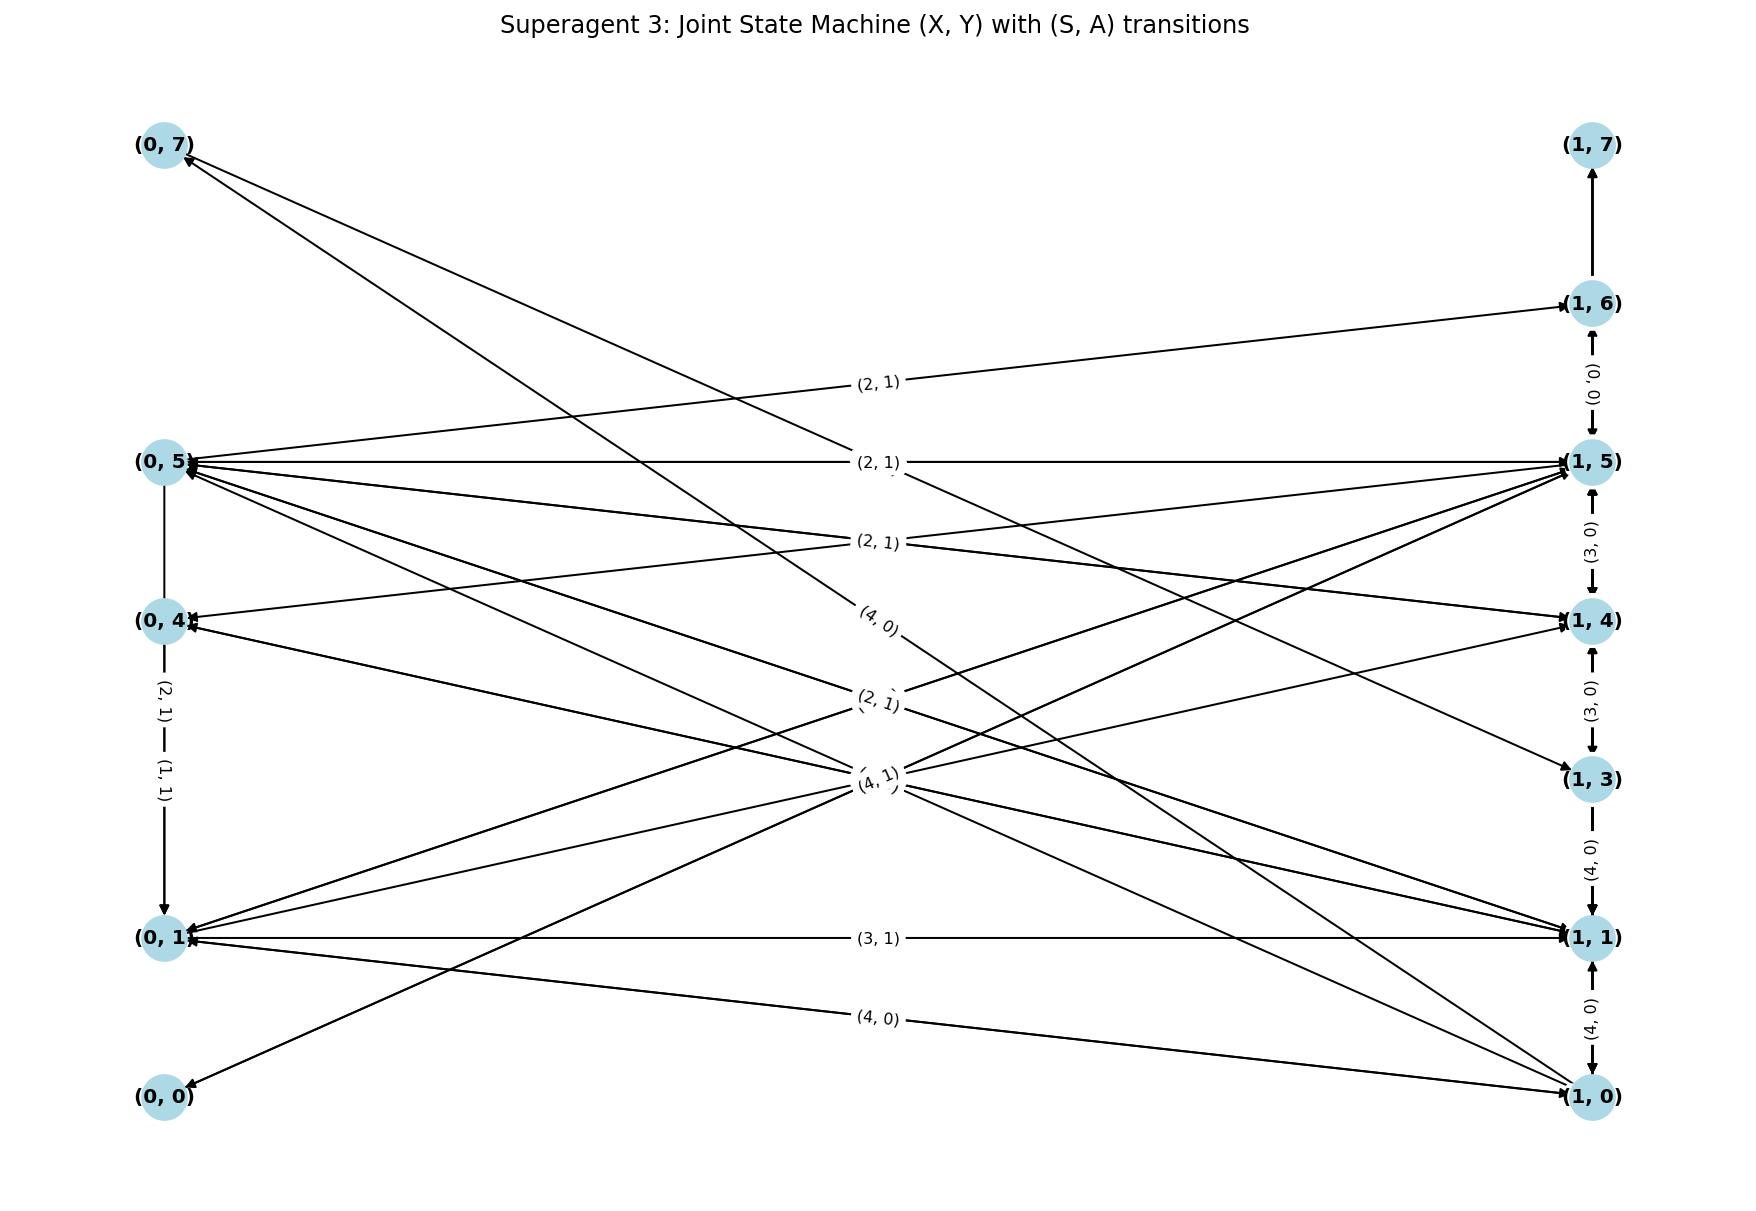

Superagent 4 (2 agents). Causal State Machine has 7 nodes and 22 edges


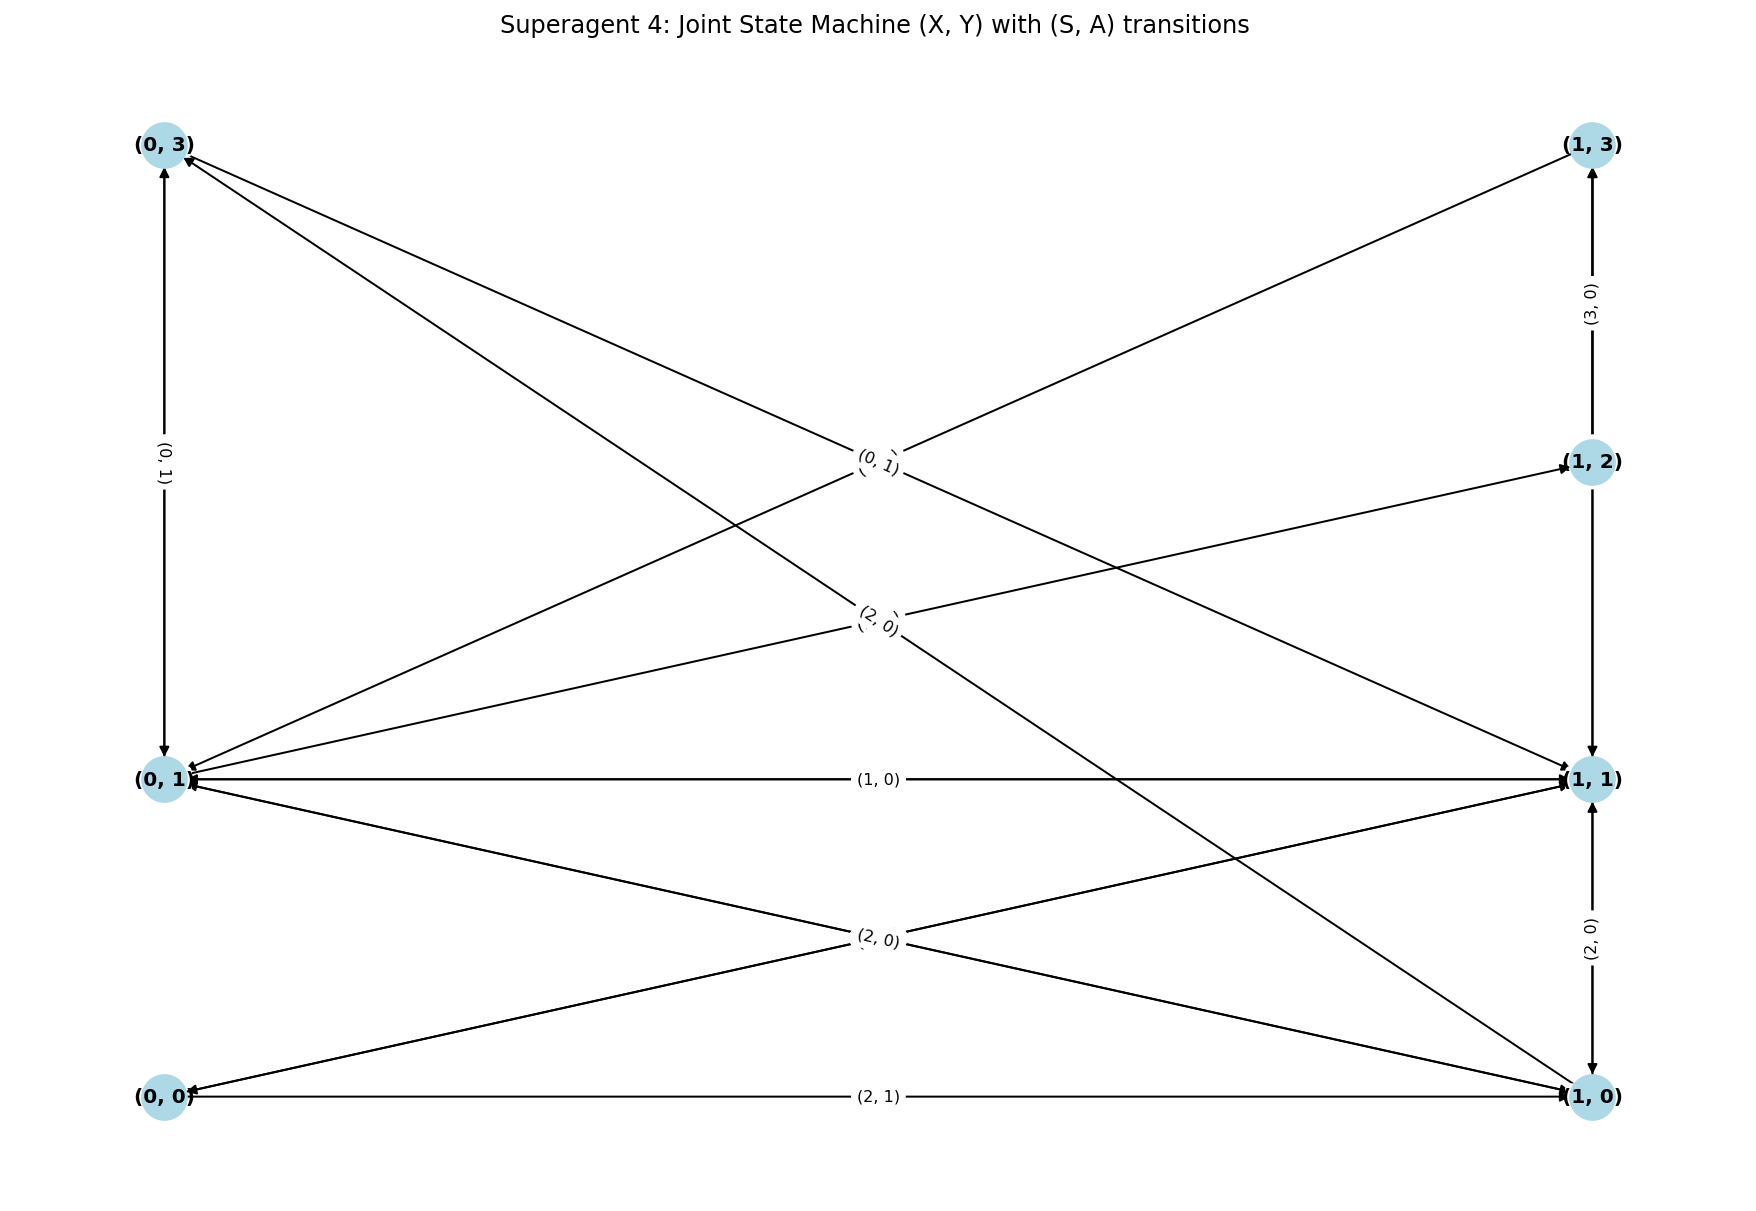

Superagent 5 (2 agents). Causal State Machine has 21 nodes and 106 edges


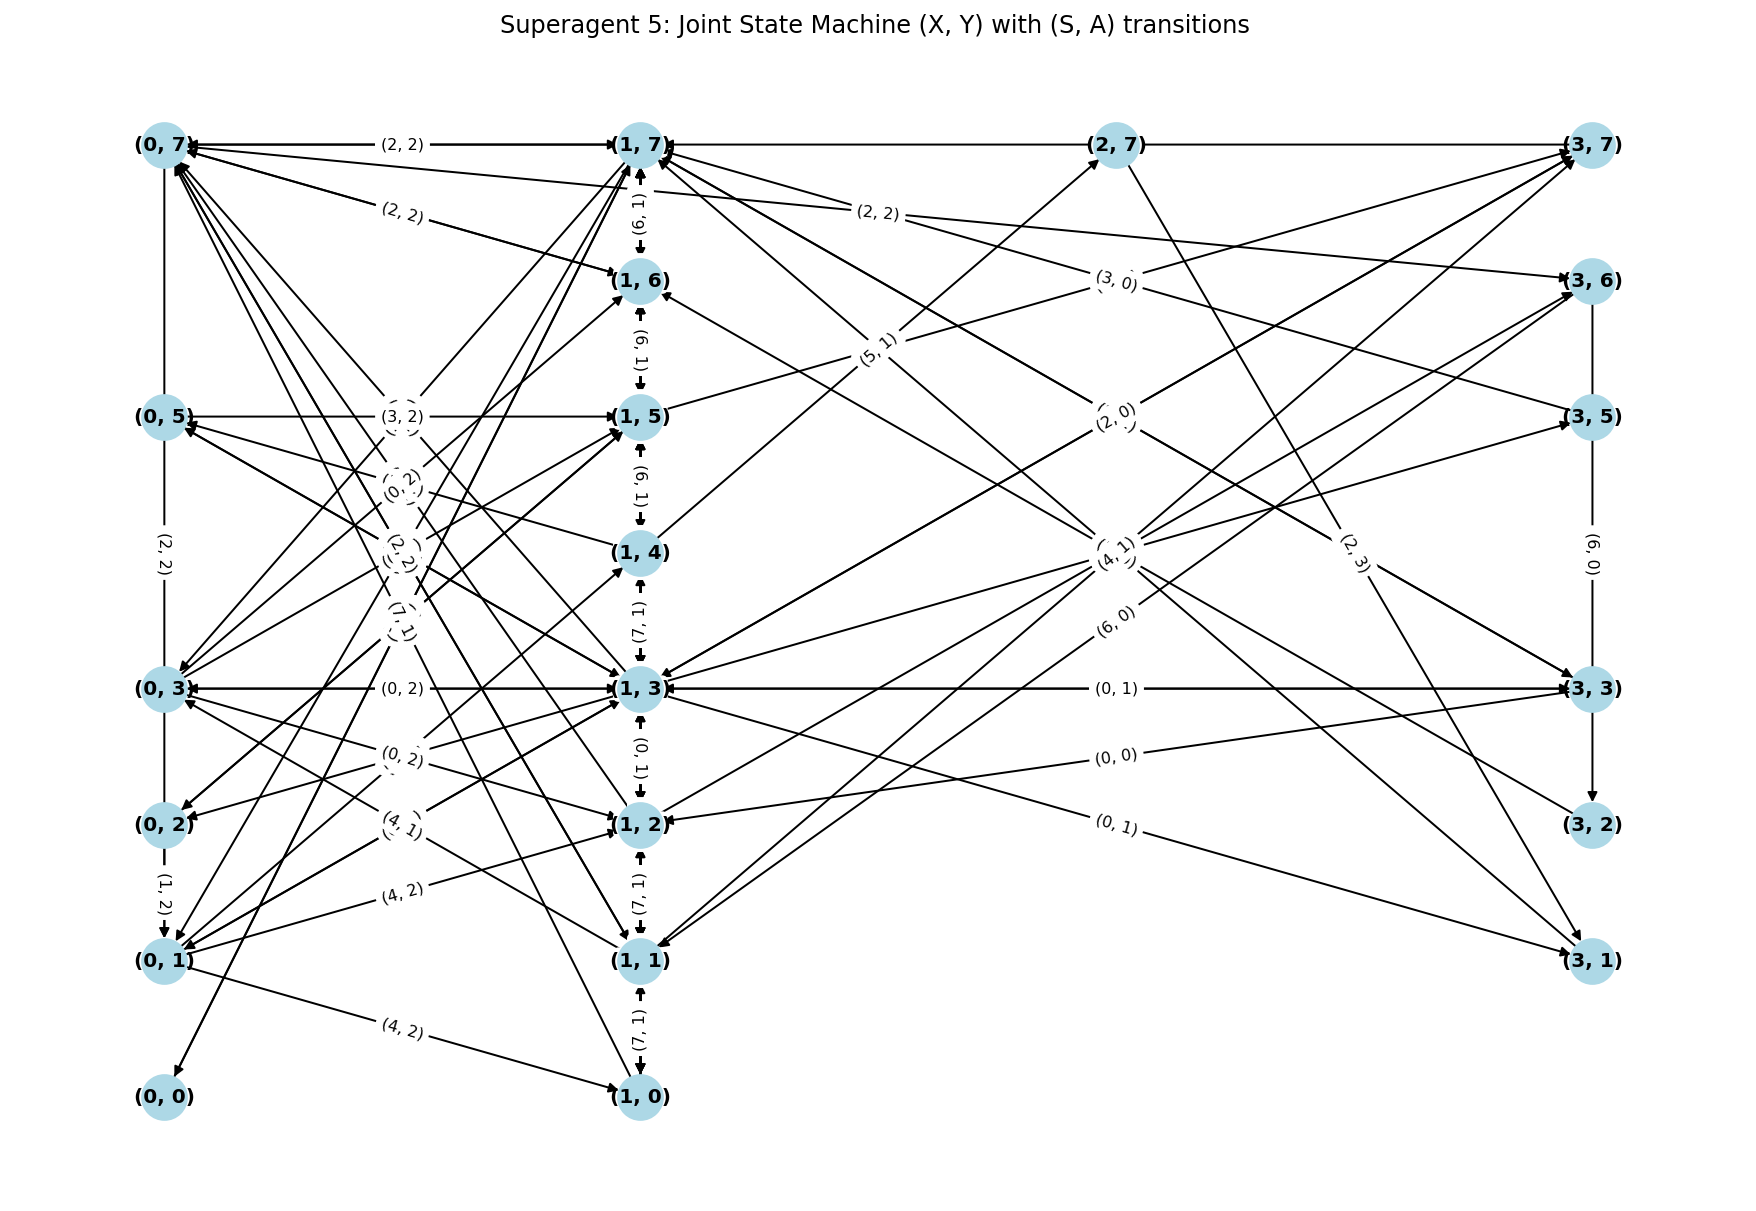

Superagent 6 (3 agents). Causal State Machine has 12 nodes and 50 edges


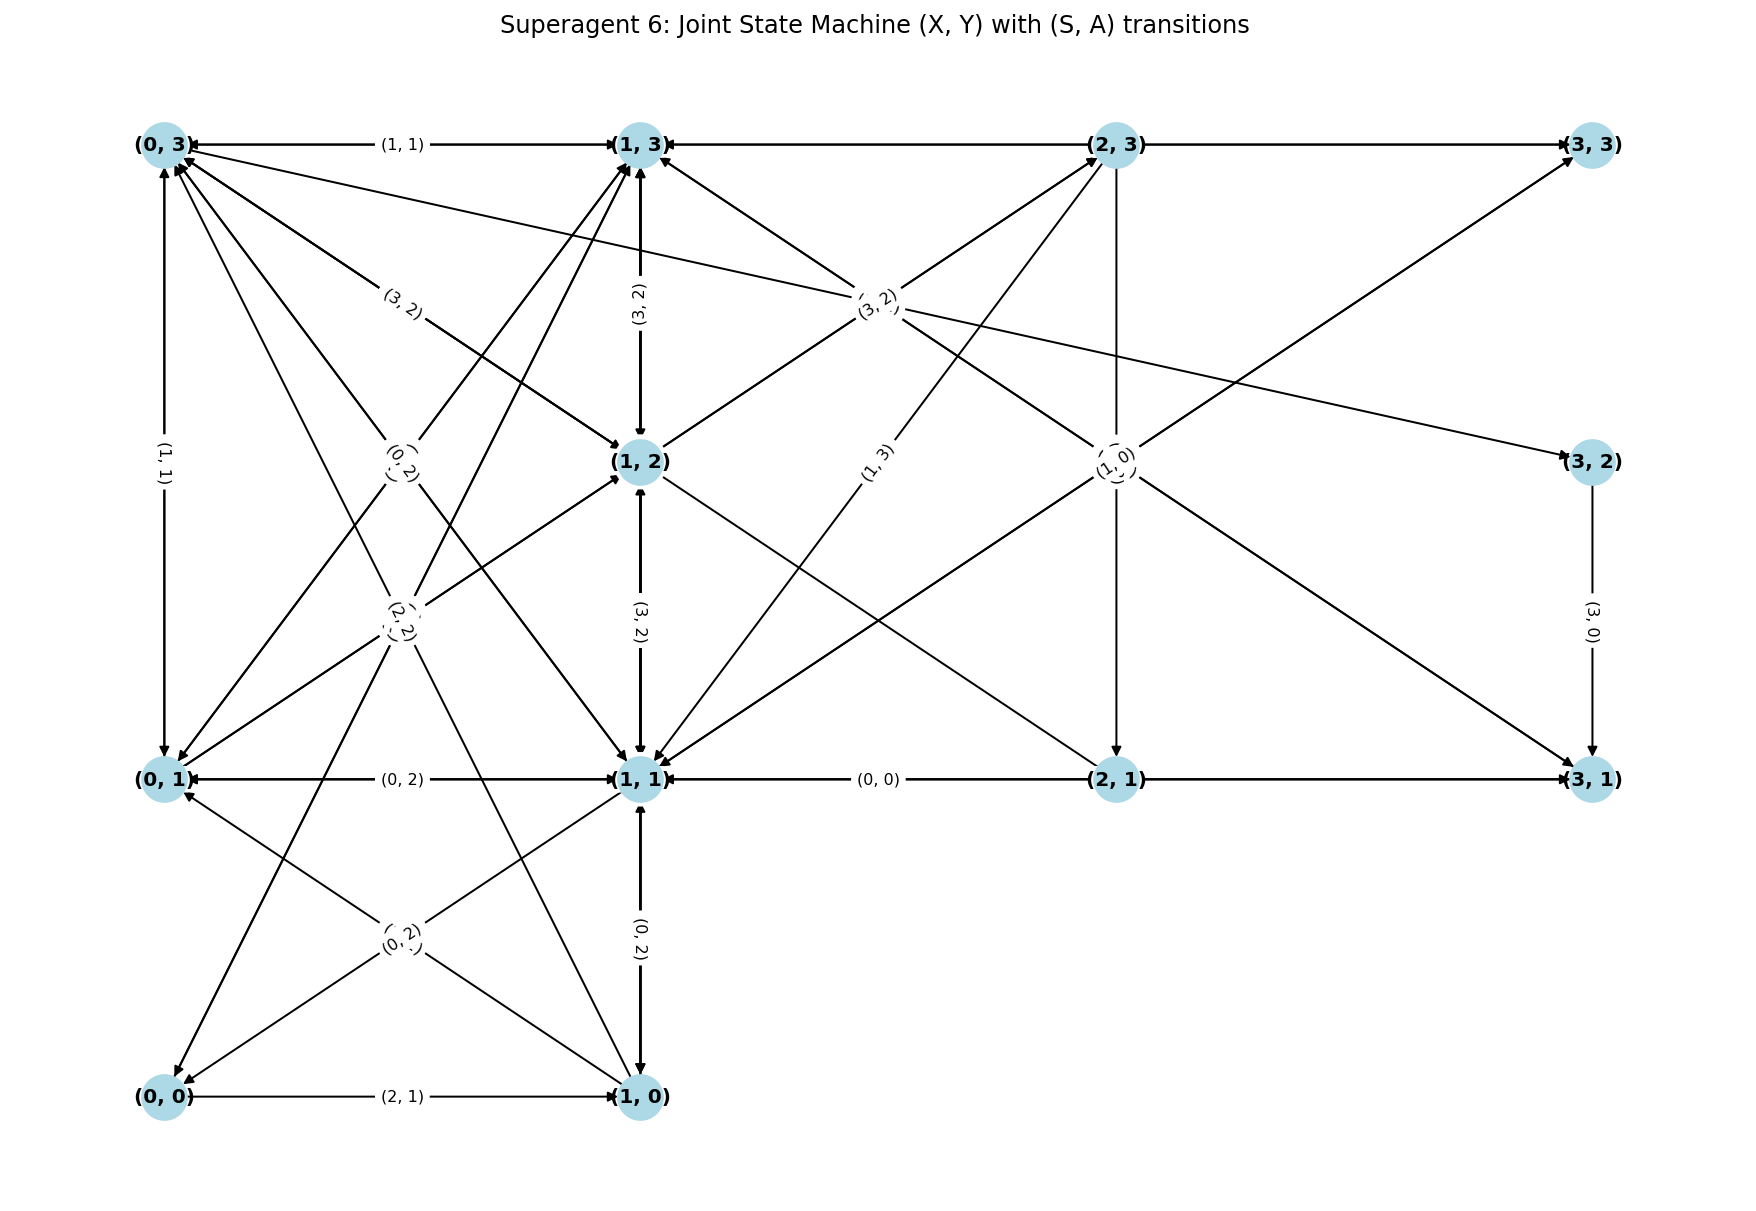

Superagent 7 (1 agents). Causal State Machine has 12 nodes and 49 edges


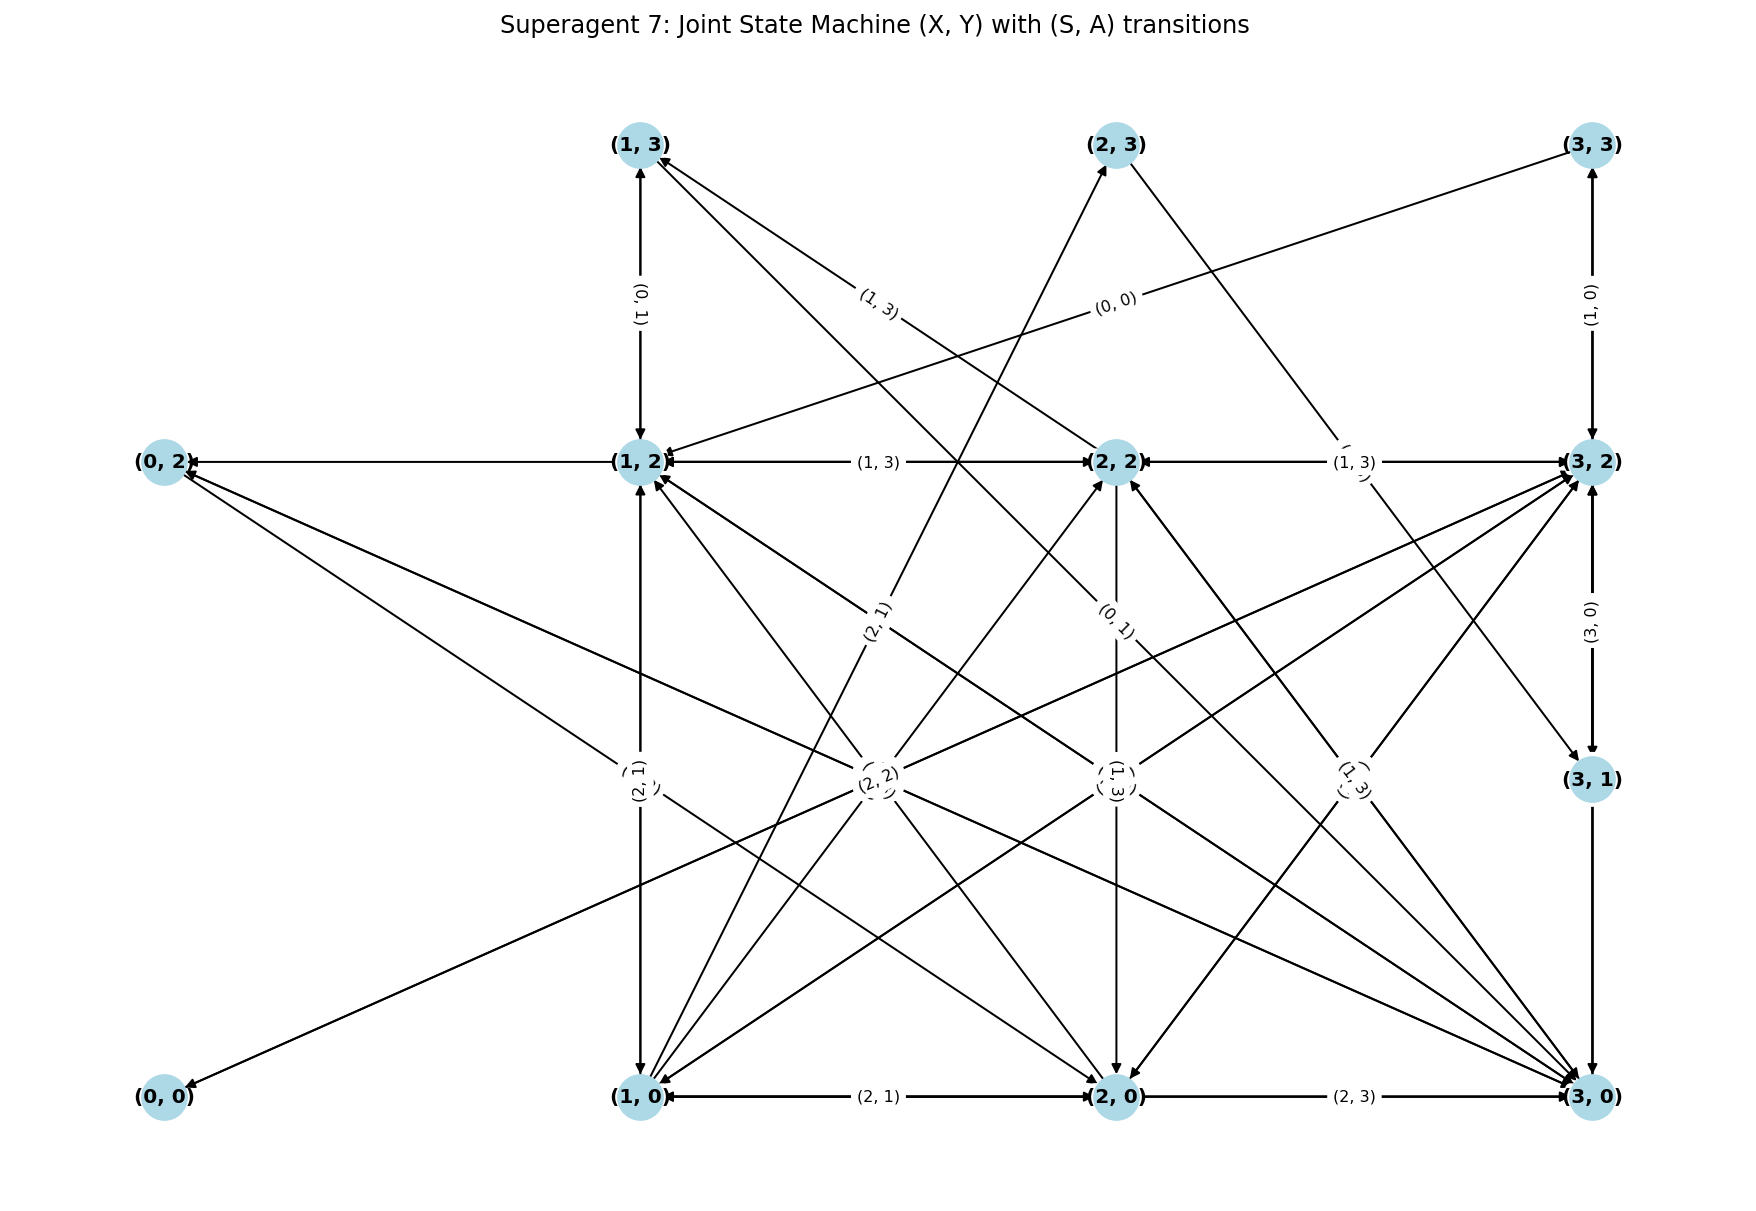

Superagent 8 (1 agents). Causal State Machine has 21 nodes and 106 edges


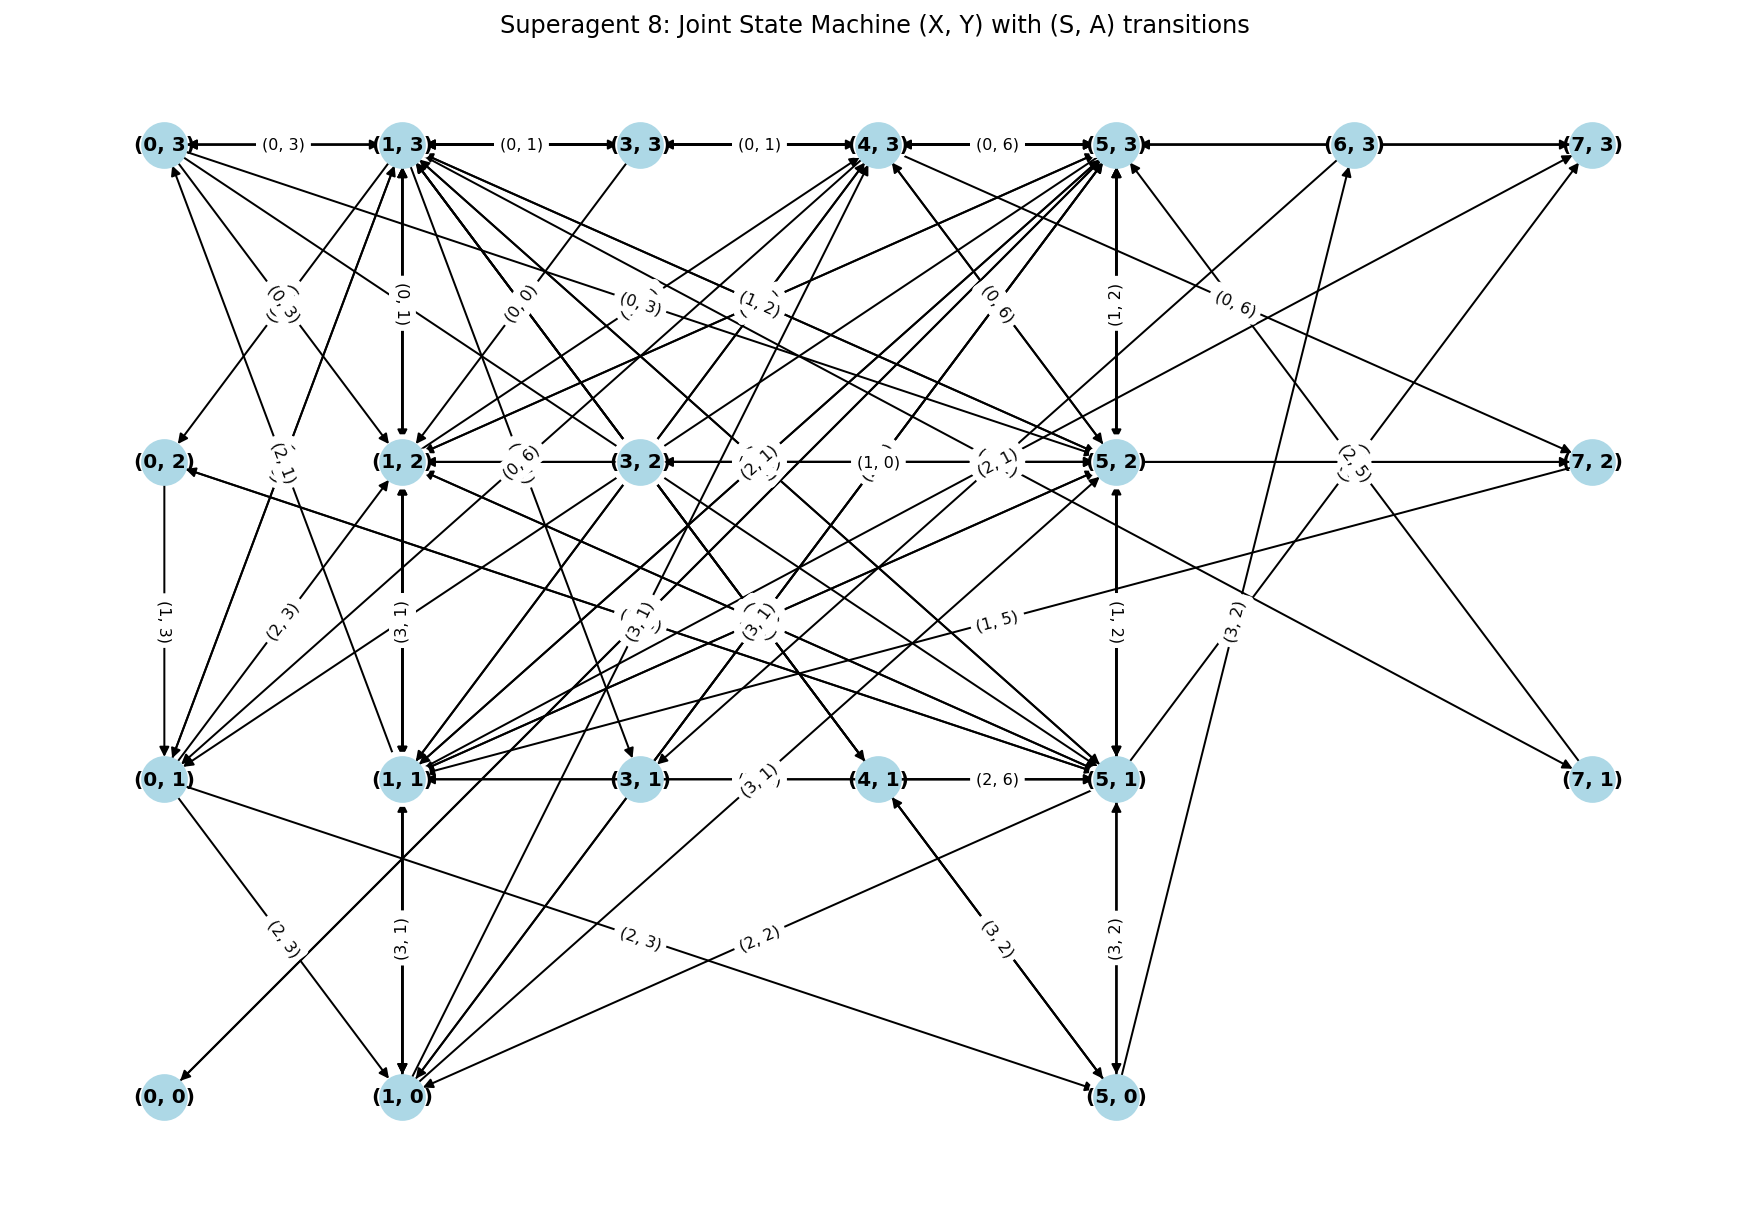

Superagent 9 (2 agents). Causal State Machine has 12 nodes and 50 edges


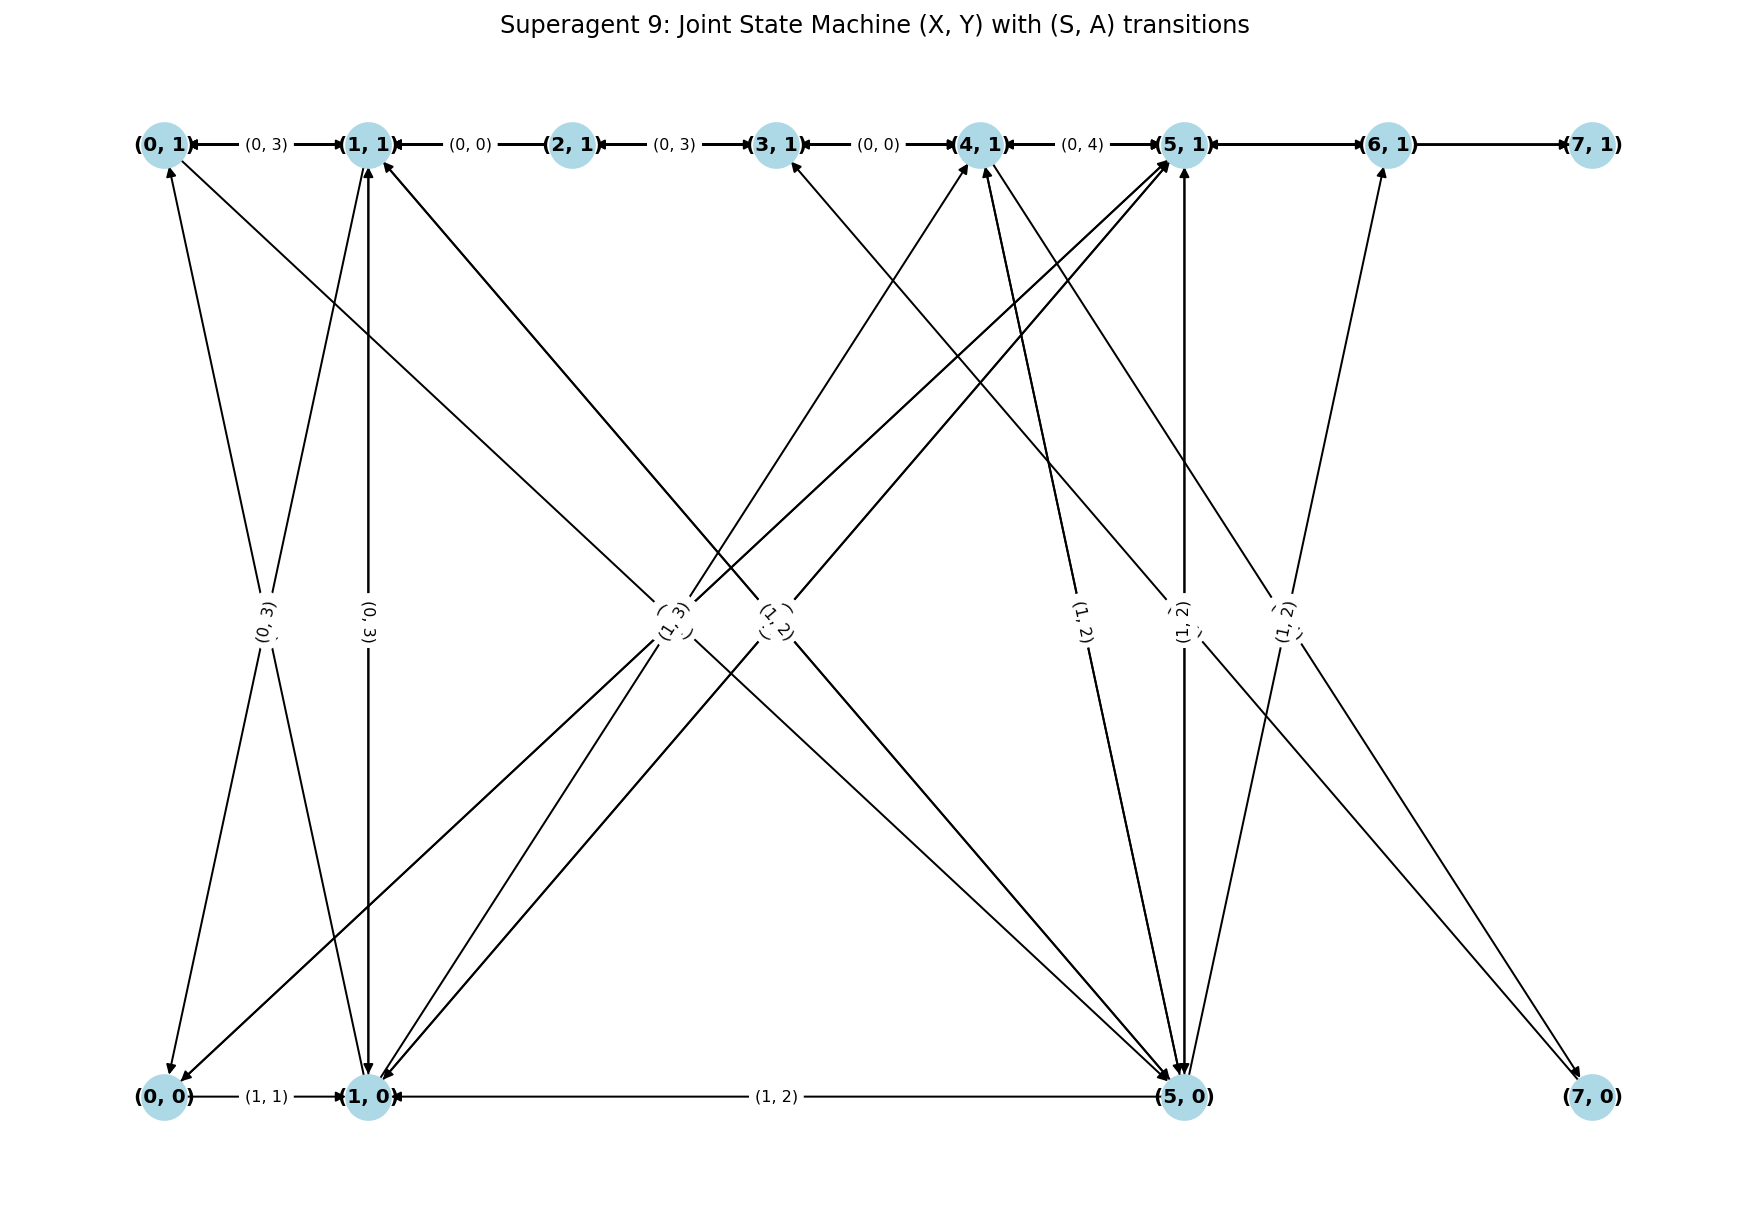

Superagent 10 (2 agents). Causal State Machine has 21 nodes and 106 edges


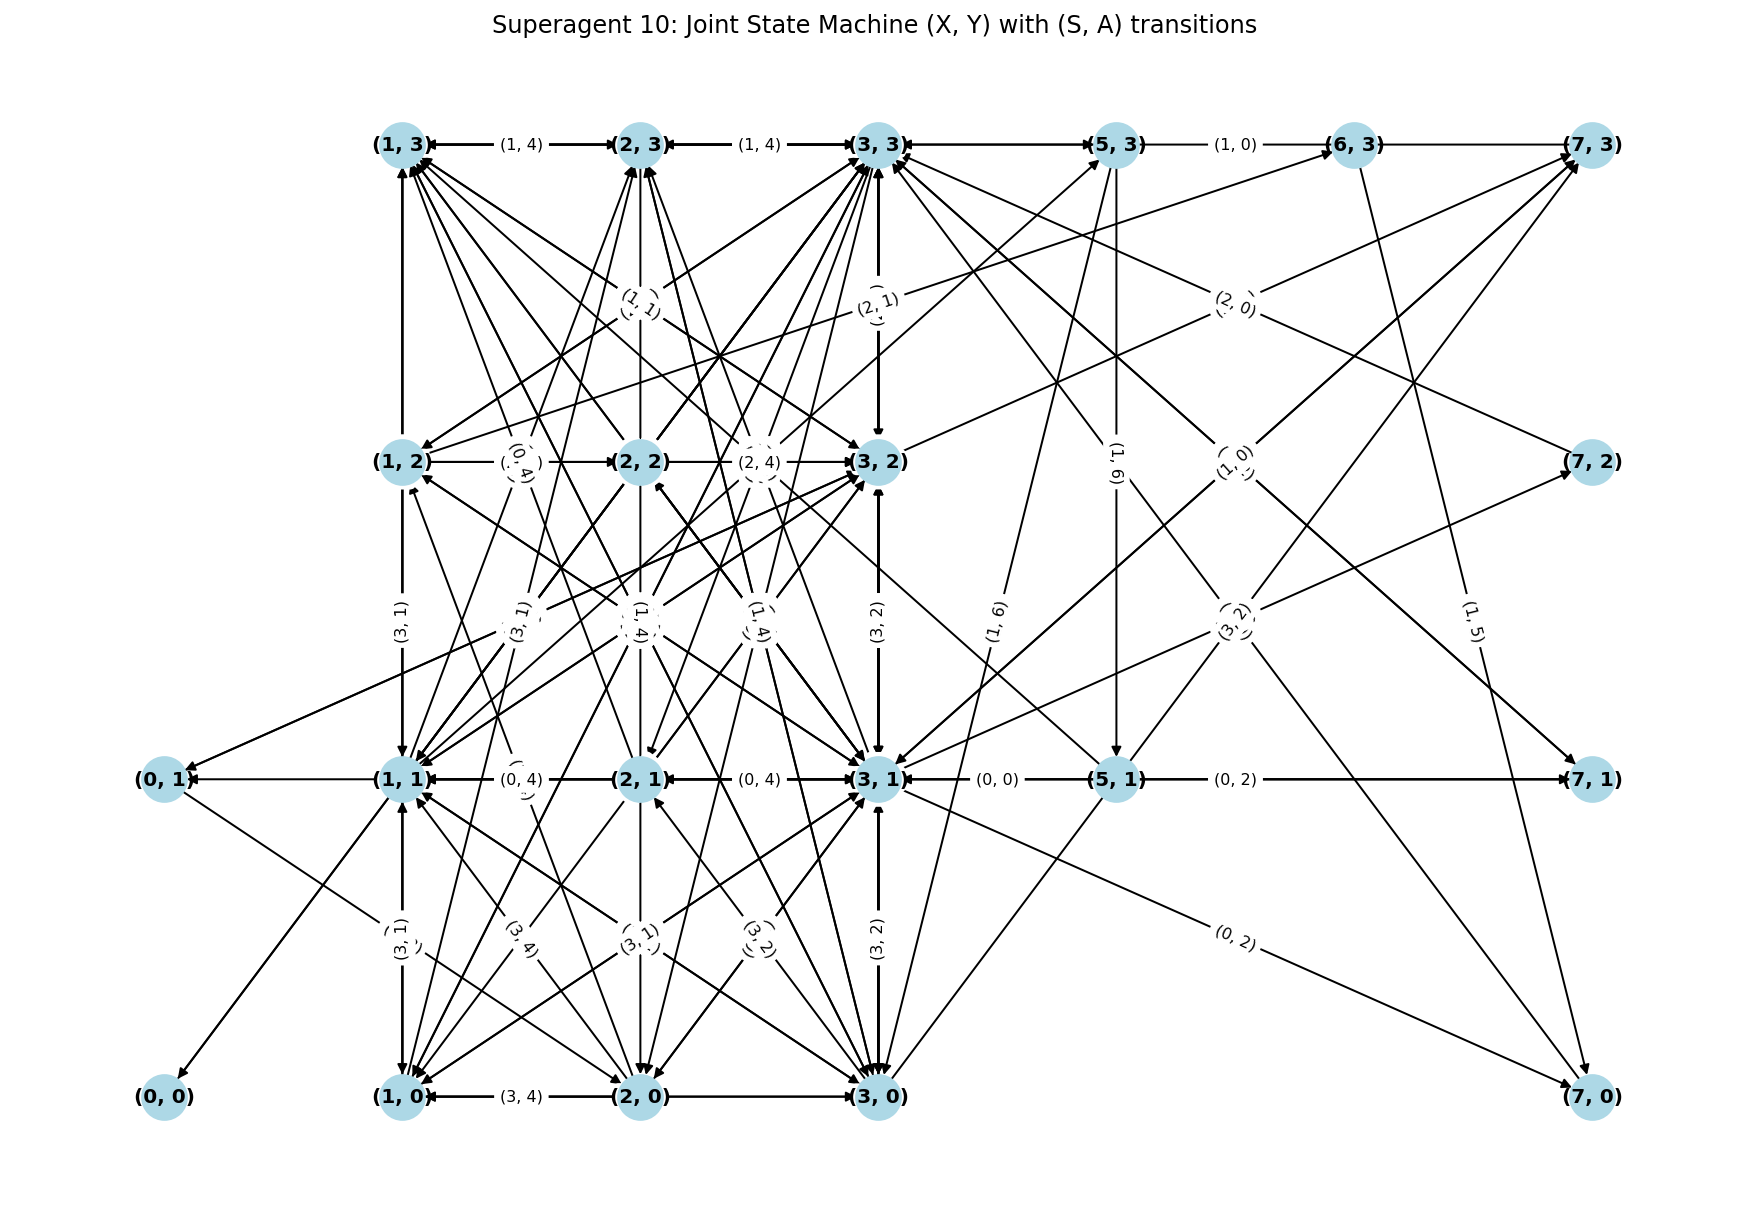

Superagent 11 (3 agents). Causal State Machine has 21 nodes and 106 edges


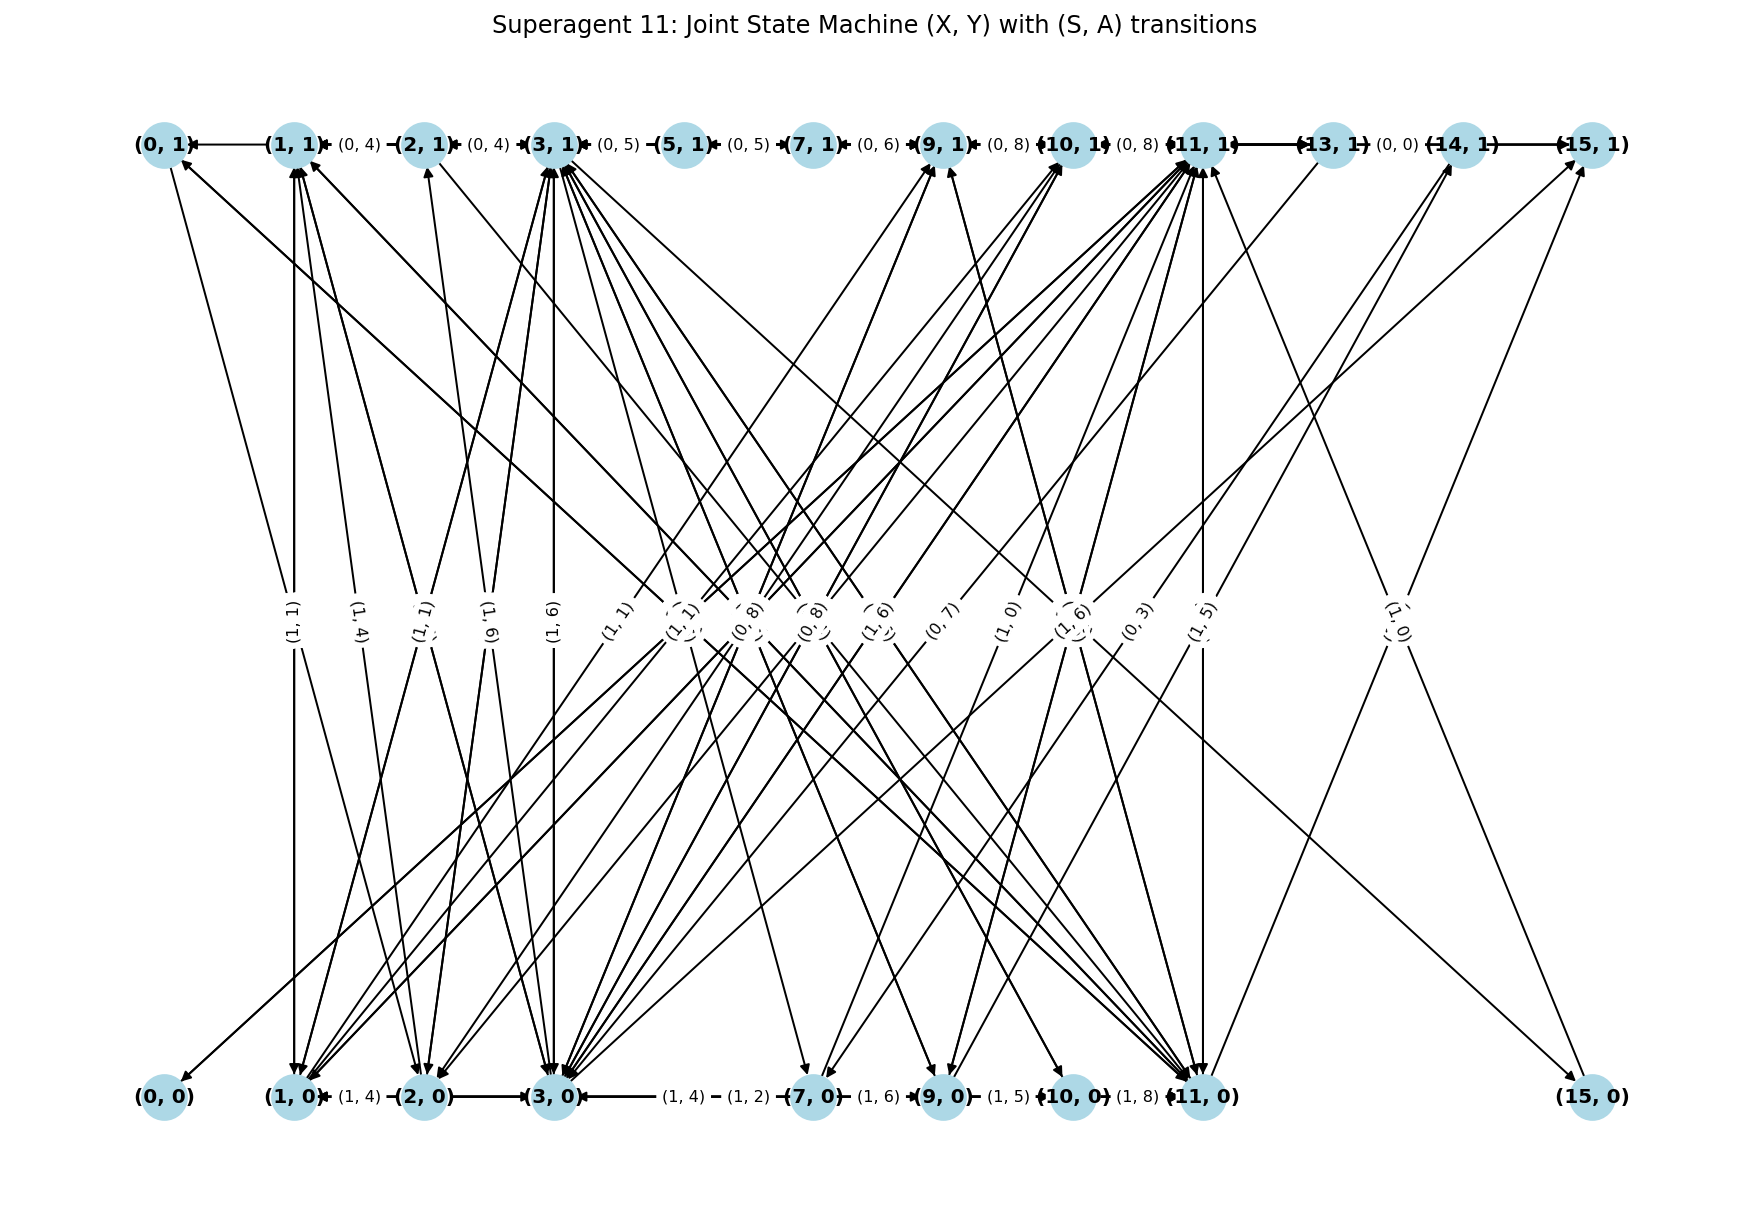

Superagent 12 (3 agents). Causal State Machine has 4 nodes and 13 edges


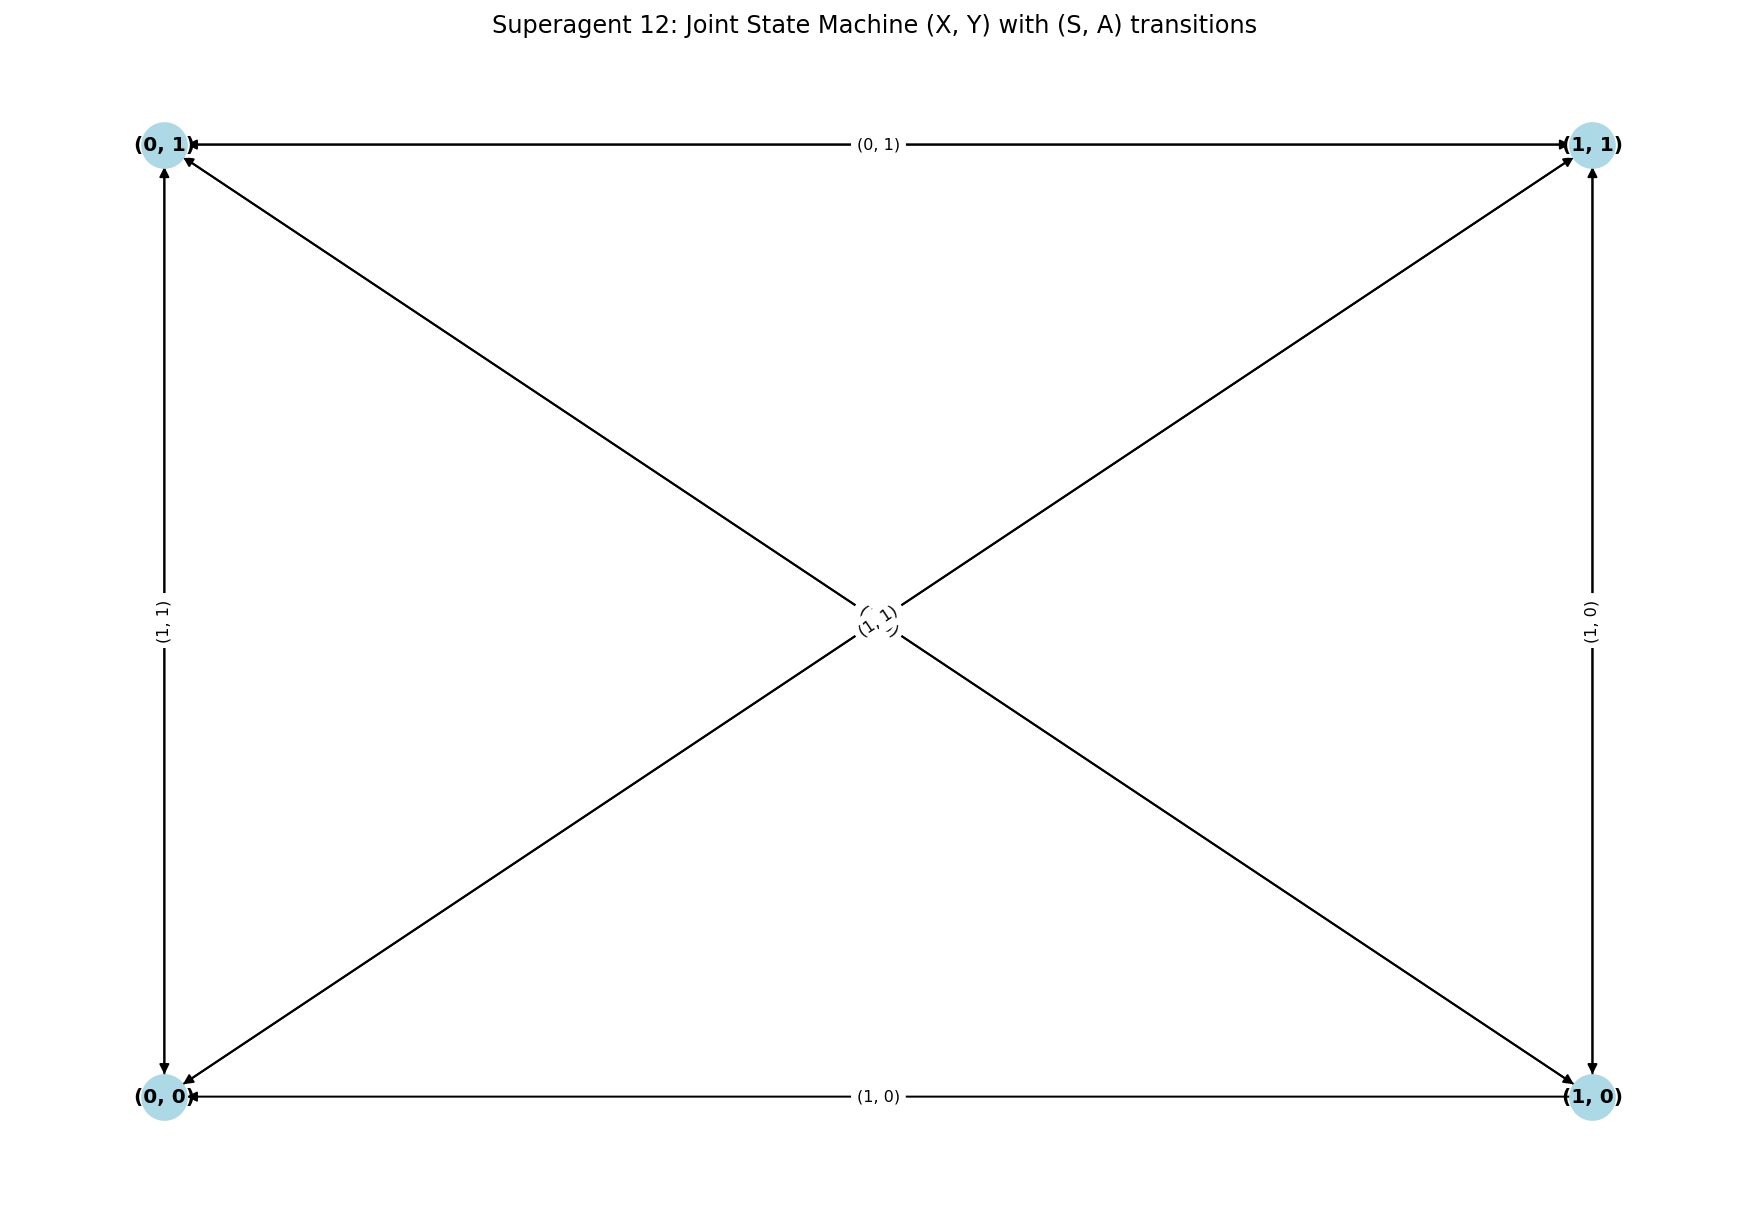

Superagent 13 (3 agents). Causal State Machine has 12 nodes and 49 edges


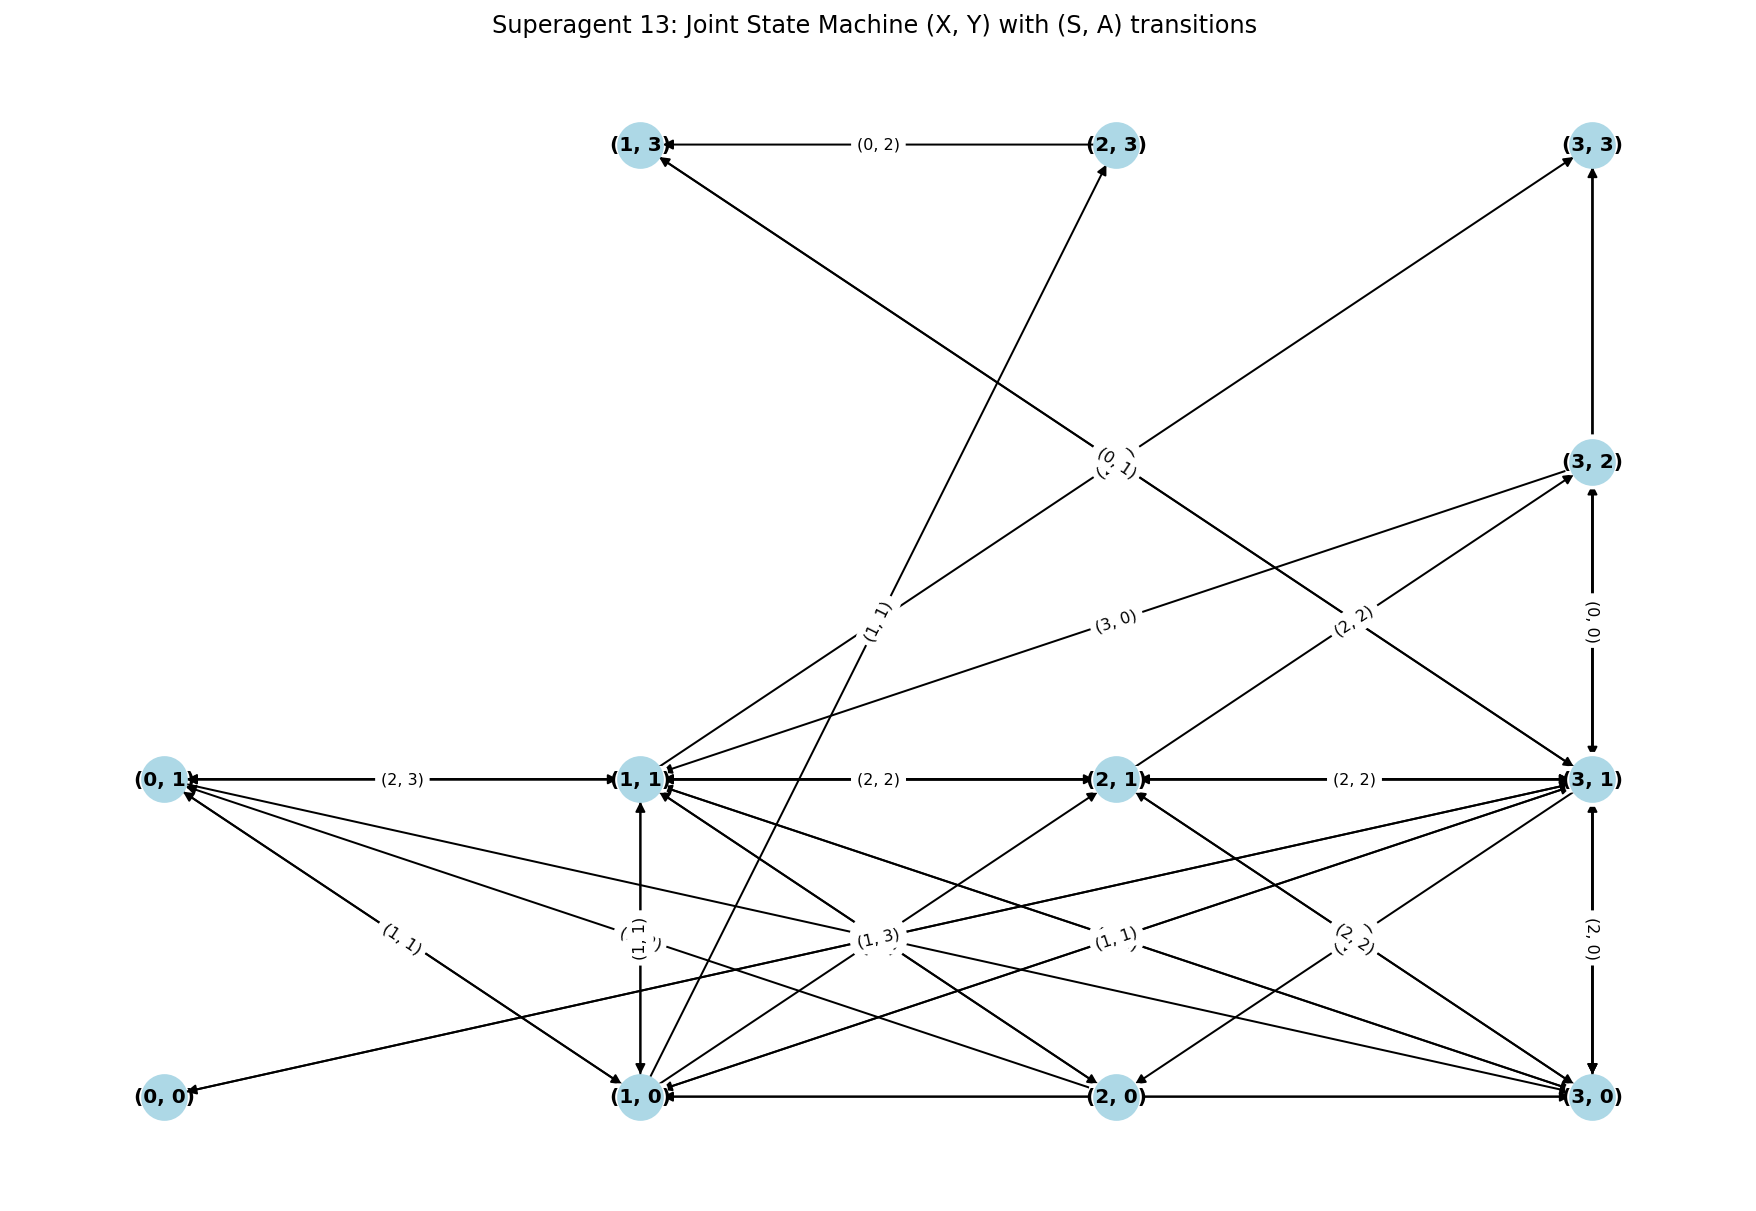

Superagent 14 (3 agents). Causal State Machine has 21 nodes and 106 edges


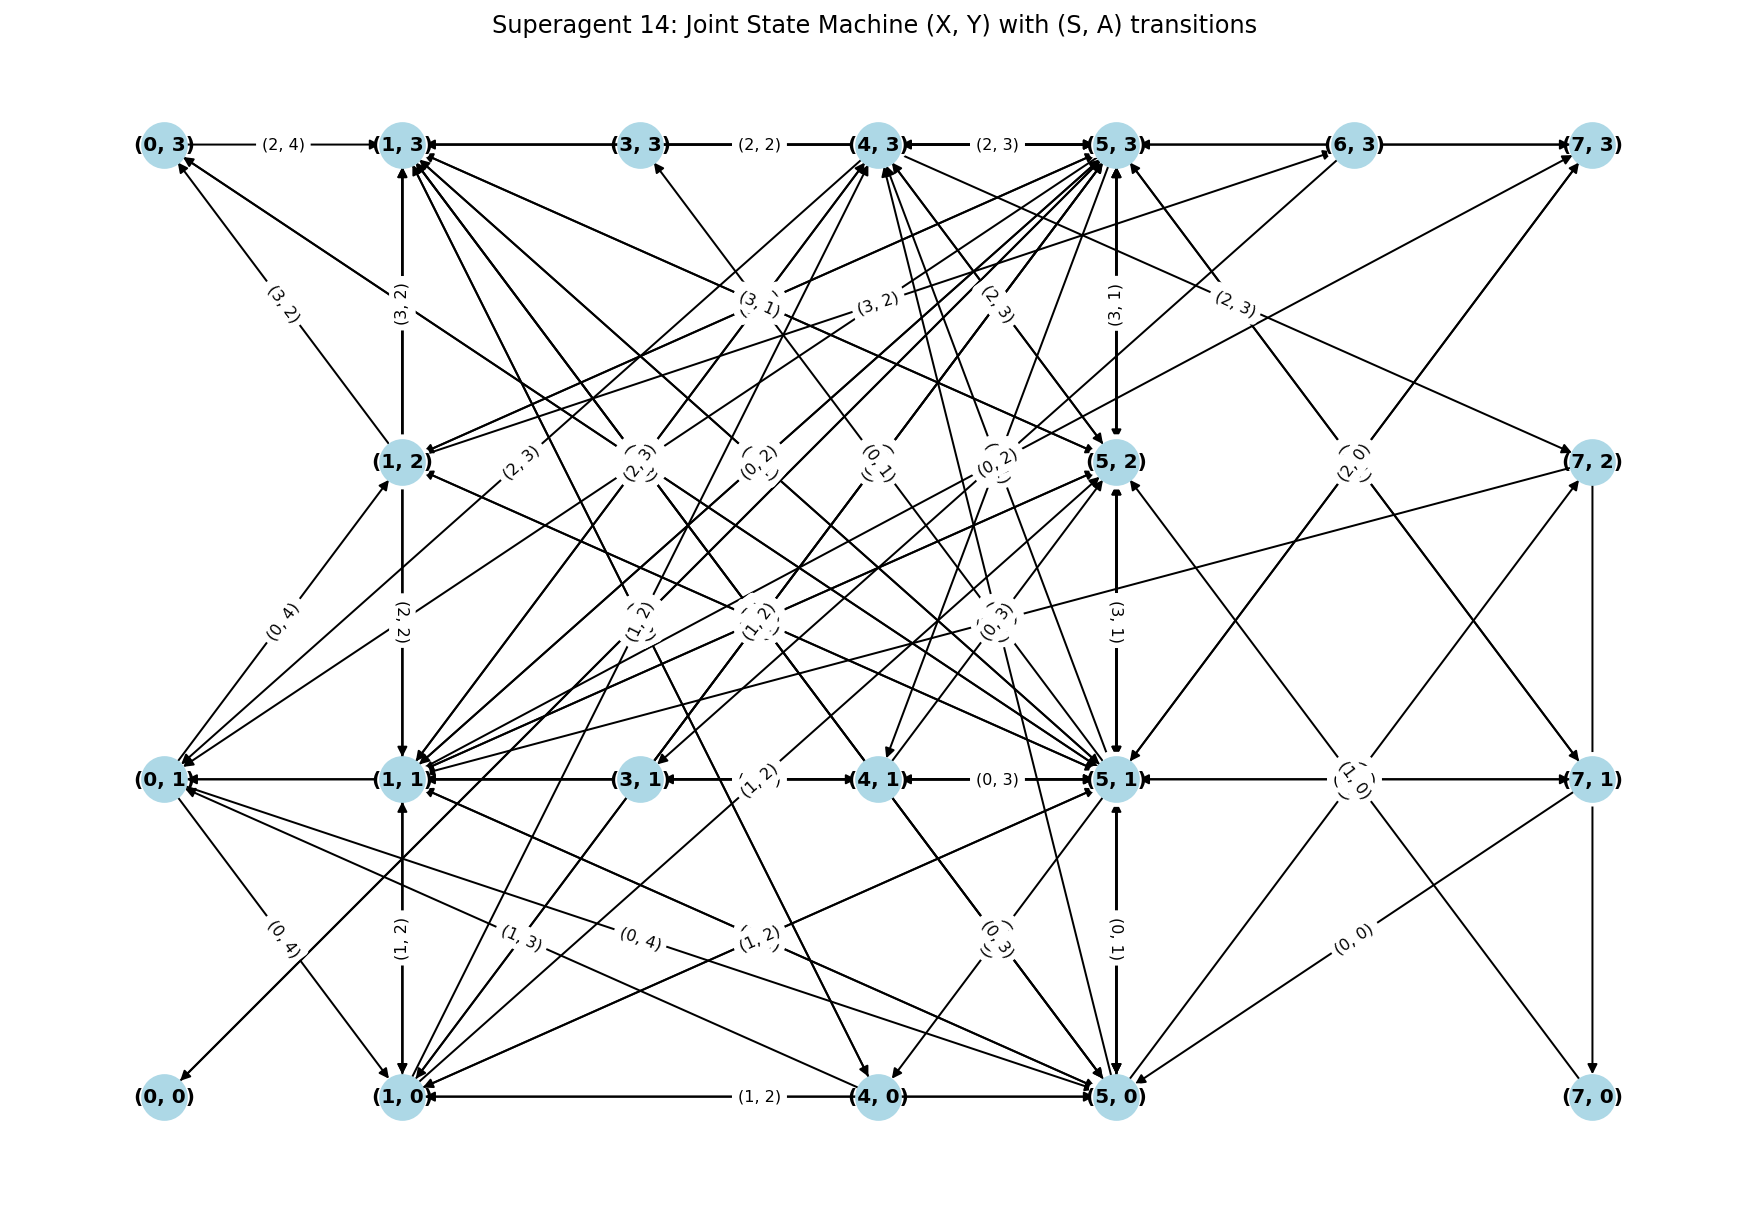

Superagent 15 (4 agents). Causal State Machine has 12 nodes and 49 edges


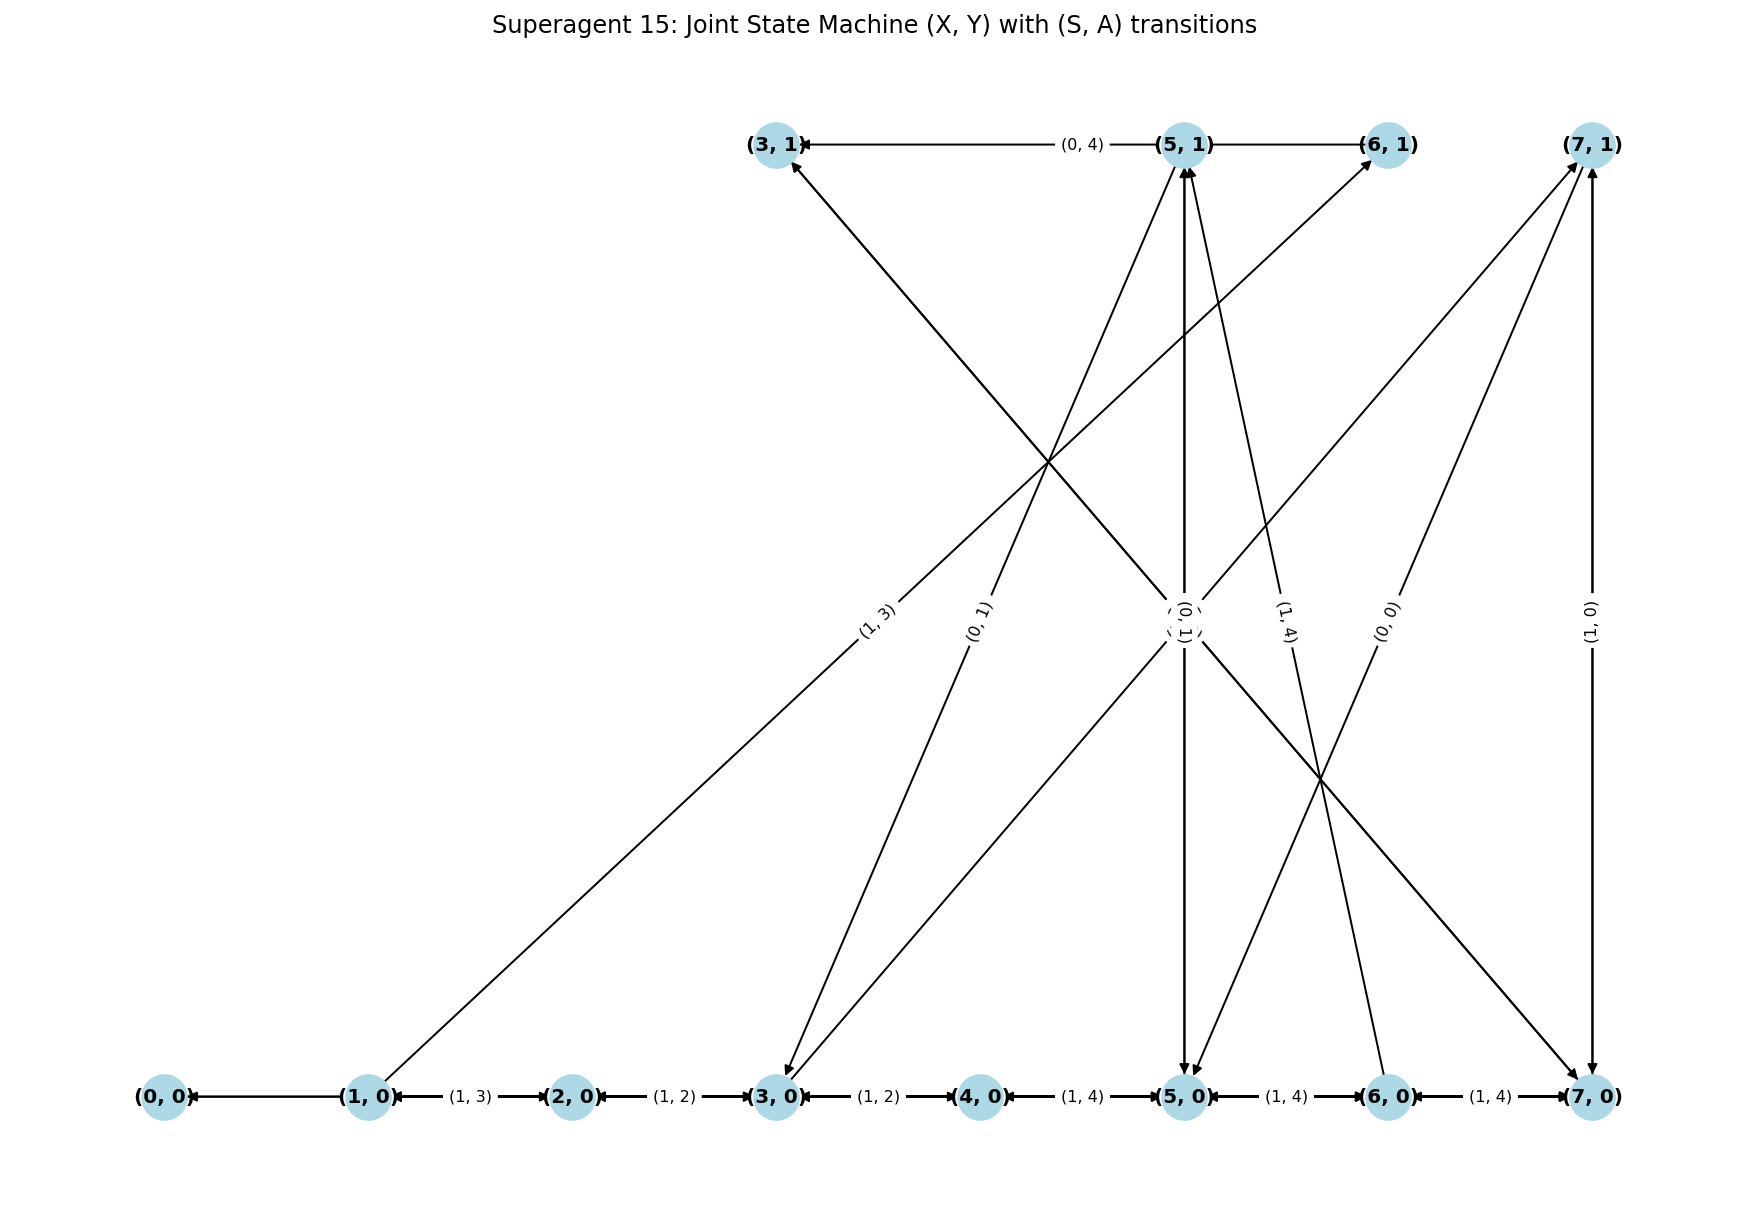

Superagent 16 (4 agents). Causal State Machine has 21 nodes and 106 edges


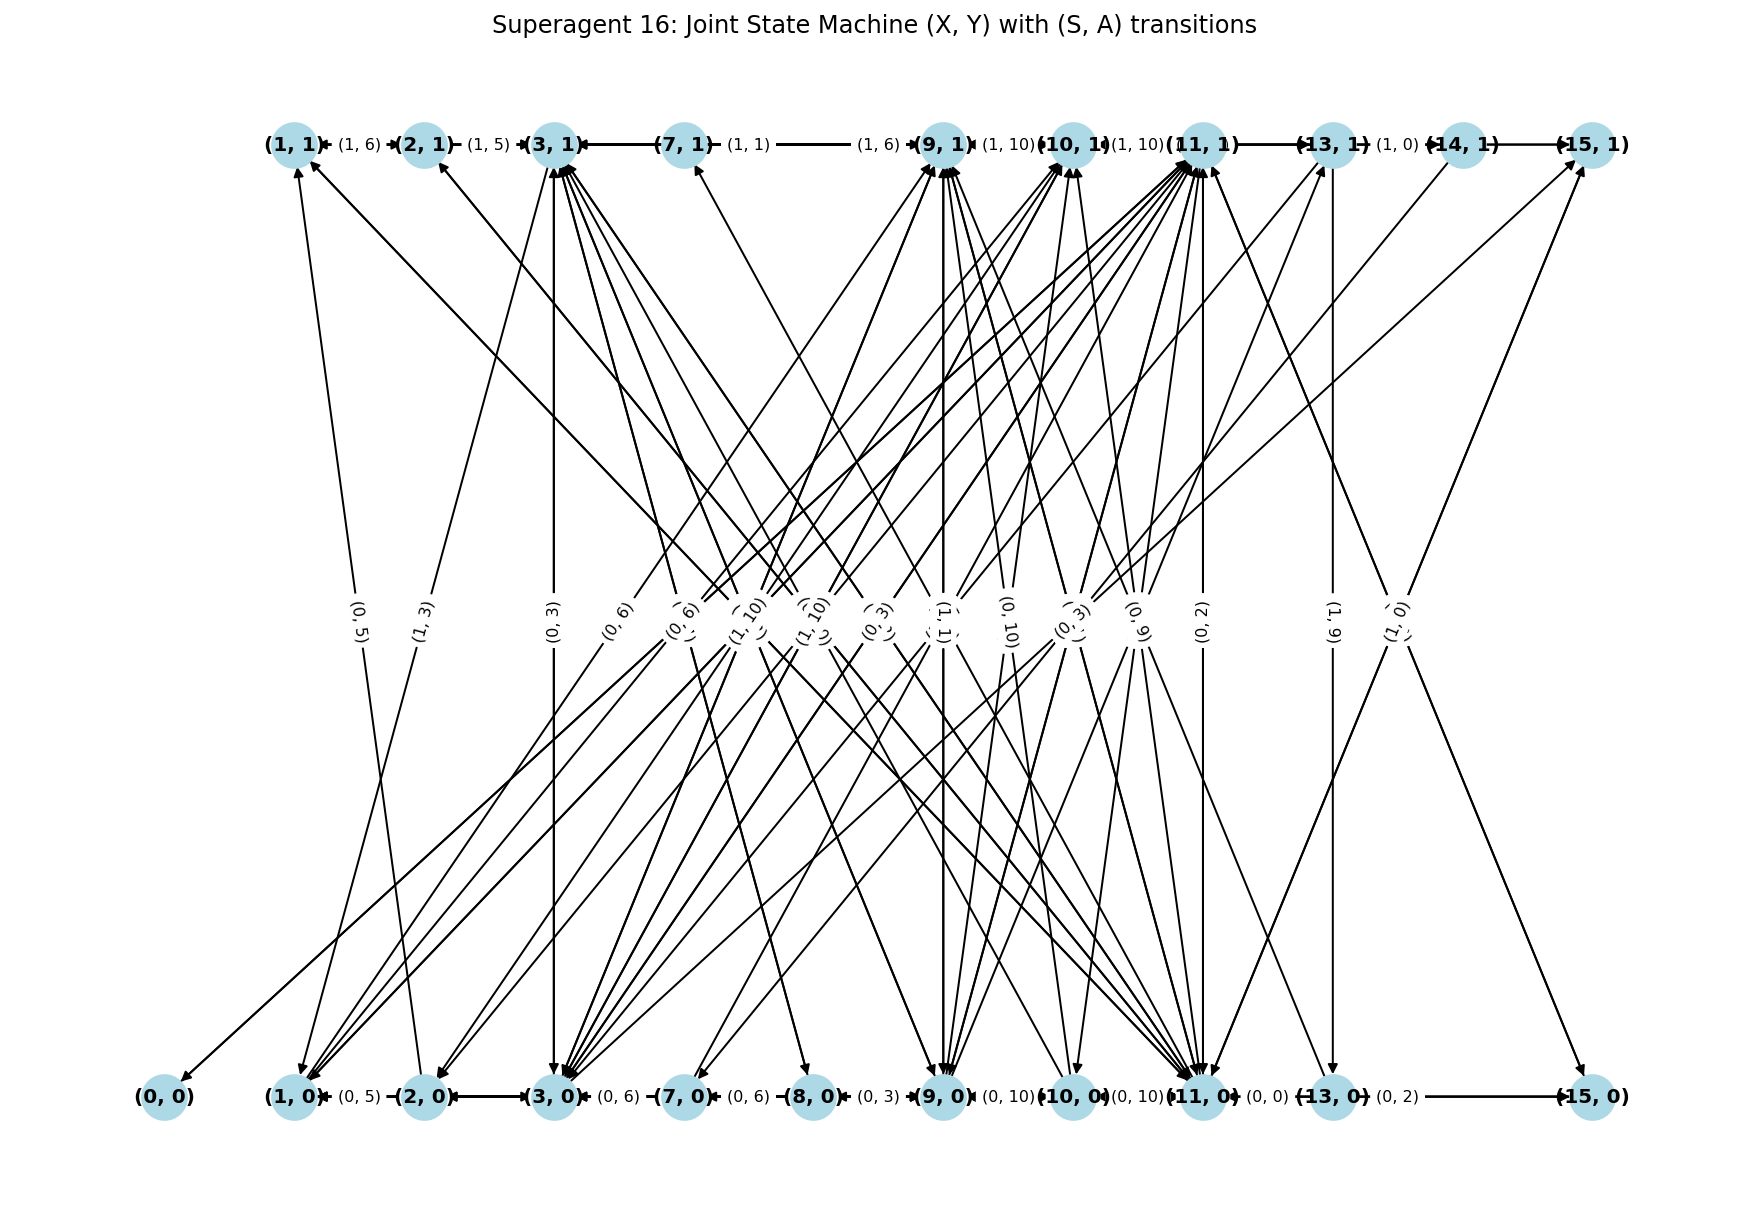

Superagent 17 (4 agents). Causal State Machine has 21 nodes and 106 edges


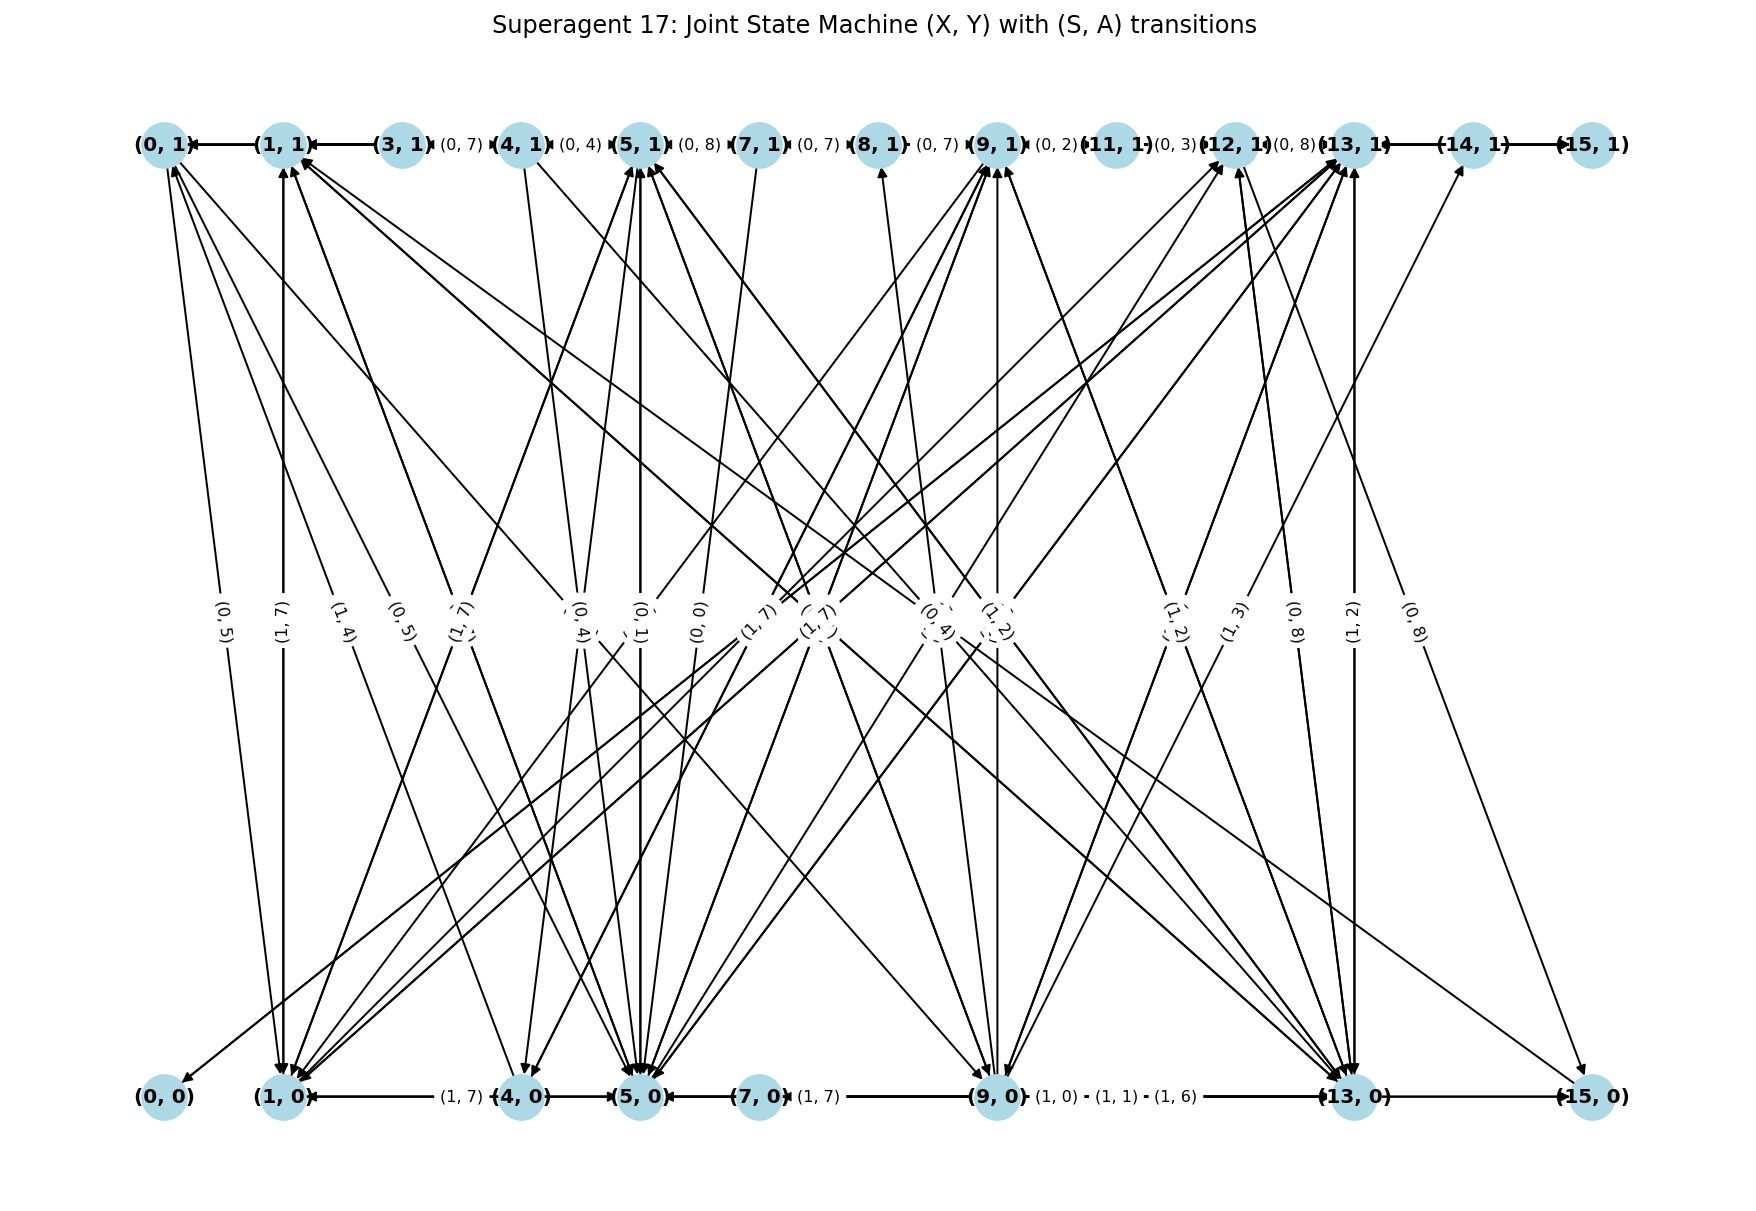

Superagent 18 (5 agents). Causal State Machine has 0 nodes and 0 edges


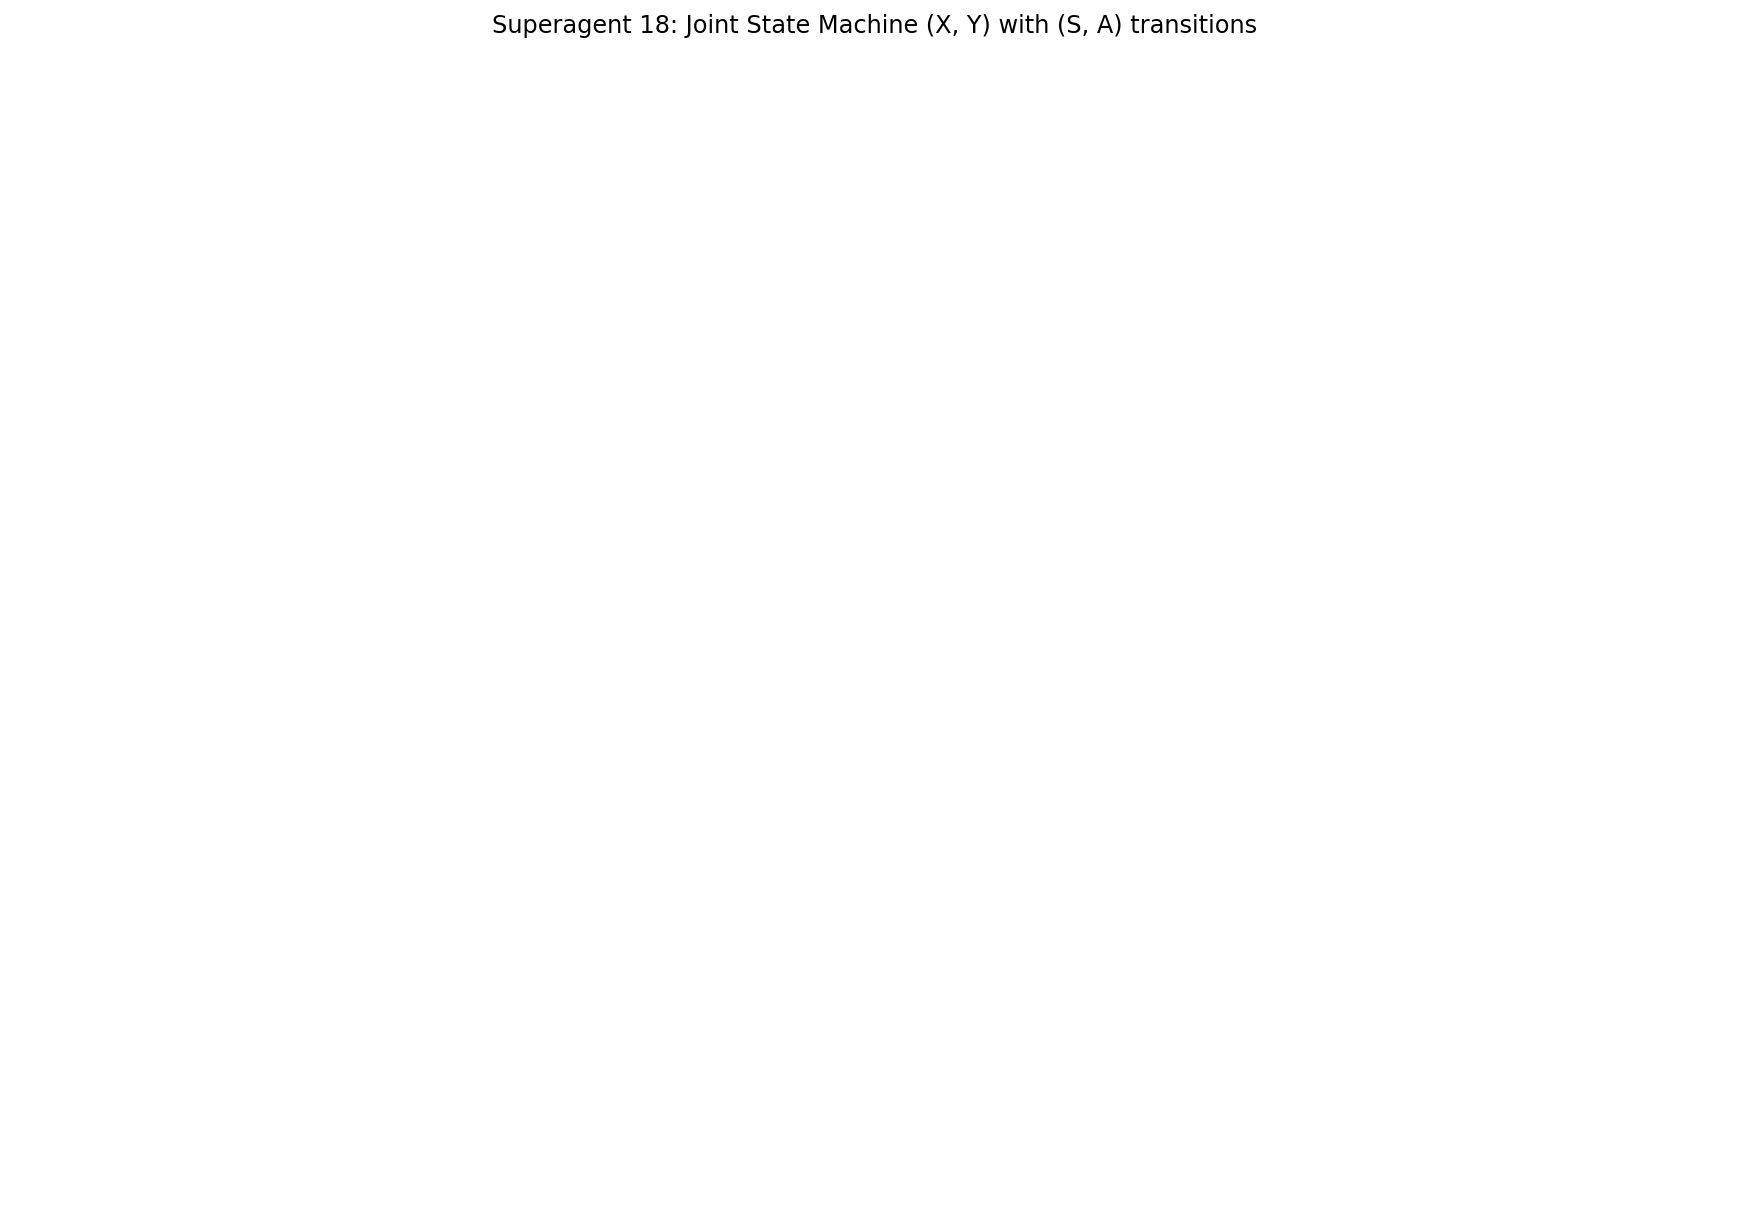

In [87]:
all_num_state_machine_nodes = []
for superagent_idx in range(len(all_partition_timeseries)):
    
    joint_state_machine = build_joint_state_machine(
        all_X_sub_flat_decimal[superagent_idx],
        all_Y_sub_flat_decimal[superagent_idx],
        all_S_cs[superagent_idx],
        all_A_cs[superagent_idx]
    )
    print(f'Superagent {superagent_idx} ({superagent_sizes[superagent_idx]} agents). Causal State Machine has {len(joint_state_machine.nodes())} nodes and {len(joint_state_machine.edges())} edges')

    plot_joint_state_machine(
        joint_state_machine, 
        title=f"Superagent {superagent_idx}: Joint State Machine (X, Y) with (S, A) transitions "
    )
    all_num_state_machine_nodes.append(len(joint_state_machine.nodes()))


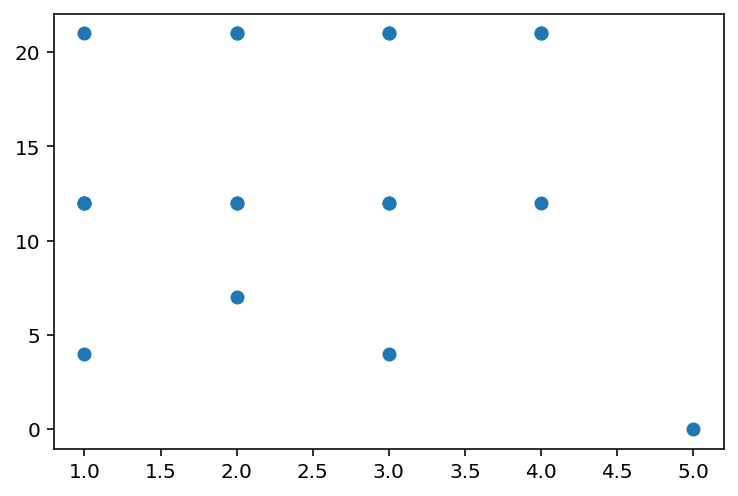

In [86]:
plt.scatter(
    superagent_sizes,
    all_num_state_machine_nodes,
)